# The Blockbuster Formula
### A Two-Layer Model of Box Office Success (2000-2025)

This notebook studies a commercially important question: **what drives a film toward Blockbuster, Hit, Break-even, or Flop territory, and how did those odds change before, during, and after COVID?**

Rather than forcing one model to do everything, the analysis uses a **two-layer structure**:

1. **Bayesian Network = explanation engine**
   Uses four interpretable pre-release features to model the probability of each of the four commercial outcomes.
2. **Gradient Boosting = prediction engine**
   Uses a richer feature set already available in the repo to predict whether a film becomes a **Blockbuster** or **Not Blockbuster**.
3. **Era analysis = market context**
   Shows how the background theatrical environment changed from the early 2000s through the COVID shock and the post-COVID streaming era.

The explanation layer is designed to answer questions like:

- **How does budget tier shift the odds of each outcome?**
- **Which genres structurally scale toward blockbuster status?**
- **How much does actor prestige really matter once budget and genre are known?**
- **Does release timing add meaningful signal after the bigger decisions are fixed?**

The prediction layer answers a different question:

- **Given the stronger signals already present in the dataset, can we detect blockbuster likelihood more accurately?**

That distinction matters. The Bayesian Network is valuable because it is interpretable and probabilistic, not because it is the highest-accuracy classifier in the notebook. The Gradient Boosting model handles the pure prediction job.

The workflow covers the full pipeline end to end:

1. **Set up the project environment** and load the tools used throughout the analysis.
2. **Collect and merge film-level data** for releases between 2000 and 2025.
3. **Clean and standardize the dataset** so records are usable and comparable.
4. **Engineer commercially meaningful features** including inflation-adjusted finance variables, outcome labels, and actor prestige.
5. **Explore the data visually** to understand outcome distributions, revenue patterns, and broad market behavior.
6. **Train and interpret a hybrid Bayesian Network** as the explanation engine.
7. **Run probabilistic inference scenarios** to see how different choices shift outcome probabilities.
8. **Benchmark the explanation engine honestly** and then build a stronger binary Gradient Boosting prediction engine.
9. **Perform sensitivity analysis** to identify the strongest drivers of blockbuster probability.
10. **Conclude the main findings** and extend the analysis with an era-based view of theatrical risk over time.

The final output is not just a model, but a decision framework: **one layer explains the formula, one layer predicts blockbuster breakout, and the era analysis explains why the market itself became more fragile over time.**


## Section 0 - Setup & Imports

In [57]:
import os
import re
import time
import warnings
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx
from pathlib import Path
from dotenv import load_dotenv
from tqdm.notebook import tqdm
from bs4 import BeautifulSoup

# pgmpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, PC, BIC
from pgmpy.inference import VariableElimination
import pgmpy

# sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    multilabel_confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Paths
DATA_PATH    = Path('data')
OUTPUTS_PATH = Path('outputs')
DATA_PATH.mkdir(exist_ok=True)
OUTPUTS_PATH.mkdir(exist_ok=True)

# Colour palette used across all plots
OUTCOME_COLORS = {
    'Flop':        '#e74c3c',
    'Break-even':  '#f39c12',
    'Hit':         '#2ecc71',
    'Blockbuster': '#2980b9',
}
outcome_order = ['Flop', 'Break-even', 'Hit', 'Blockbuster']

# API
load_dotenv()
TMDB_API_KEY = os.getenv('TMDB_API_KEY')
if not TMDB_API_KEY:
    raise ValueError('TMDb API key not found. Add TMDB_API_KEY to your .env file.')

print(f'pgmpy {pgmpy.__version__} | pandas {pd.__version__} | numpy {np.__version__}')
print('All imports OK.')


pgmpy 1.1.0 | pandas 2.2.3 | numpy 2.2.3
All imports OK.


## Section 1 - Data Collection

In [58]:
# TMDb API config and helper
TMDB_BASE    = 'https://api.themoviedb.org/3'
TMDB_HEADERS = {'accept': 'application/json'}
START_YEAR   = 2000
END_YEAR     = 2025
PAGES_PER_YEAR = 10
REQUEST_DELAY  = 0.25

RAW_PATH  = DATA_PATH / 'movies_raw_v2.csv'
SUPP_PATH = DATA_PATH / 'numbers_supplement_v2.csv'
FEAT_PATH = DATA_PATH / 'movies_featured_v2.csv'

def tmdb_get(endpoint, params=None):
    url = f'{TMDB_BASE}/{endpoint}'
    all_params = {'api_key': TMDB_API_KEY}
    if params:
        all_params.update(params)
    try:
        r = requests.get(url, headers=TMDB_HEADERS, params=all_params, timeout=10)
        r.raise_for_status()
        return r.json()
    except requests.exceptions.RequestException as e:
        print(f'Request failed for {endpoint}: {e}')
        return None

test = tmdb_get('configuration')
print('TMDb connection:', 'OK' if test else 'FAILED -- check API key')


TMDb connection: OK


In [59]:
# Smart loader -- skip API calls if raw data already exists
if RAW_PATH.exists():
    df_raw = pd.read_csv(RAW_PATH, parse_dates=['release_date'])
    print(f'Raw data already exists -- loaded {len(df_raw)} rows from {RAW_PATH}')
    print(f'Date range: {df_raw["release_date"].min().year} - {df_raw["release_date"].max().year}')
    print('Skip to the Numbers supplement cell below.')
else:
    print(f'{RAW_PATH} not found -- run the cells below to fetch from TMDb.')
    df_raw = None


Raw data already exists -- loaded 4741 rows from data\movies_raw_v2.csv
Date range: 2000 - 2025
Skip to the Numbers supplement cell below.


In [60]:
# Step 1: Discover movie IDs per year -- skip if raw data already loaded
if df_raw is not None:
    print('Raw data already loaded -- skipping.')
else:
    def discover_ids(year, pages=PAGES_PER_YEAR):
        ids = []
        for page in range(1, pages + 1):
            data = tmdb_get('discover/movie', params={
                'primary_release_year': year, 'sort_by': 'popularity.desc',
                'include_adult': False, 'include_video': False,
                'page': page, 'language': 'en-US', 'with_original_language': 'en',
            })
            if data and 'results' in data:
                ids.extend([m['id'] for m in data['results']])
            time.sleep(REQUEST_DELAY)
        return ids

    print(f'Discovering IDs {START_YEAR} - {END_YEAR}...')
    all_ids = []
    for year in tqdm(range(START_YEAR, END_YEAR + 1), desc='Years'):
        all_ids.extend(discover_ids(year))
    all_ids = list(set(all_ids))
    print(f'Unique IDs collected: {len(all_ids)}')


Raw data already loaded -- skipping.


In [61]:
# Step 2: Fetch details + credits -- skip if raw data already loaded
if df_raw is not None:
    print('Raw data already loaded -- skipping.')
else:
    def fetch_details(movie_id):
        details = tmdb_get(f'movie/{movie_id}', params={'language': 'en-US'})
        if not details:
            return None
        credits = tmdb_get(f'movie/{movie_id}/credits', params={'language': 'en-US'})
        cast_list, cast_ids = [], []
        if credits and 'cast' in credits:
            top = sorted(credits['cast'], key=lambda x: x.get('order', 99))[:5]
            cast_list = [c['name'] for c in top]
            cast_ids  = [str(c['id']) for c in top]
        return {
            'tmdb_id': movie_id,
            'title': details.get('title', ''),
            'release_date': details.get('release_date', ''),
            'genres': '|'.join(g['name'] for g in details.get('genres', [])),
            'budget': details.get('budget', 0),
            'revenue': details.get('revenue', 0),
            'runtime': details.get('runtime', 0),
            'popularity': details.get('popularity', 0),
            'vote_average': details.get('vote_average', 0),
            'vote_count': details.get('vote_count', 0),
            'original_language': details.get('original_language', ''),
            'cast_names': '|'.join(cast_list),
            'cast_ids':   '|'.join(cast_ids),
        }

    print(f'Fetching details for {len(all_ids)} movies...')
    movies, failed = [], []
    for mid in tqdm(all_ids, desc='Movies'):
        rec = fetch_details(mid)
        if rec: movies.append(rec)
        else:   failed.append(mid)
        time.sleep(REQUEST_DELAY)   
    print(f'Fetched: {len(movies)}  |  Failed: {len(failed)}')


Raw data already loaded -- skipping.


In [62]:
# Step 3: Build DataFrame and save
if df_raw is not None:
    print('Raw data already loaded -- skipping build.')
else:
    df_raw = pd.DataFrame(movies)
    df_raw['release_date'] = pd.to_datetime(df_raw['release_date'], errors='coerce')
    df_raw['release_year'] = df_raw['release_date'].dt.year
    df_raw.to_csv(RAW_PATH, index=False)
    print(f'Saved {len(df_raw)} rows to {RAW_PATH}')

print(f'Shape: {df_raw.shape}')
df_raw.head(3)


Raw data already loaded -- skipping build.
Shape: (4741, 14)


,tmdb_id,title,release_date,genres,budget,revenue,runtime,popularity,vote_average,vote_count,original_language,cast_names,cast_ids,release_year
0,8193,Napoleon Dynamite,2004-06-11,Comedy,400000,46118097,95,3.4054,6.783,2127,en,Jon Heder|Efren Ramirez|Tina Majorino|Aaron Ru...,53926|20190|53930|53927|9629,2004
1,8198,The Quiet American,2002-11-22,Romance|Thriller|Drama|War,30000000,27674124,101,1.5456,6.545,325,en,Michael Caine|Brendan Fraser|Đỗ Thị Hải Yến|Tz...,3895|18269|53962|21629|1118,2002
2,614409,To All the Boys: Always and Forever,2021-02-12,Romance|Comedy|Drama,0,0,114,2.8253,7.502,2054,en,Lana Condor|Noah Centineo|Janel Parrish|Anna C...,1452046|1253353|93377|1683266|1299232,2021


In [63]:
# Raw data overview
print('=== Raw Data Summary ===')
print(f'Total rows:         {len(df_raw)}')
print(f'Budget  > 0:        {(df_raw["budget"] > 0).sum()}')
print(f'Revenue > 0:        {(df_raw["revenue"] > 0).sum()}')
print(f'Both zero:          {((df_raw["budget"]==0) & (df_raw["revenue"]==0)).sum()}')
print(f'Date range:         {df_raw["release_date"].min().date()} to {df_raw["release_date"].max().date()}')
bnz = df_raw[df_raw['budget']  > 0]['budget']
rnz = df_raw[df_raw['revenue'] > 0]['revenue']
print(f'Budget  min/med/max: ${bnz.min():,.0f} / ${bnz.median():,.0f} / ${bnz.max():,.0f}')
print(f'Revenue min/med/max: ${rnz.min():,.0f} / ${rnz.median():,.0f} / ${rnz.max():,.0f}')


=== Raw Data Summary ===
Total rows:         4741
Budget  > 0:        3551
Revenue > 0:        3599
Both zero:          869
Date range:         2000-01-01 to 2025-12-28
Budget  min/med/max: $5 / $30,000,000 / $489,900,000
Revenue min/med/max: $7 / $54,700,000 / $2,923,706,026


In [64]:
# The Numbers budget supplement
# Fills in missing production budgets for films TMDb has at $0 but revenue > $5M.
# Cached to SUPP_PATH. Set FORCE_REFETCH=True to re-scrape.

FORCE_REFETCH = False
TN_BASE    = 'https://www.the-numbers.com/movie/'
TN_HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

def _tn_slug(title, year=None):
    t = title.strip()
    for art in ['The ', 'A ', 'An ']:
        if t.startswith(art):
            t = t[len(art):] + '-' + art.strip()
            break
    t = re.sub(r"[\u2019\u2018']", '', t)
    t = re.sub(r'[^a-zA-Z0-9-]', '-', t)
    t = re.sub(r'-+', '-', t).strip('-')
    return f'{t}-({year})' if year else t

def _tn_parse(html):
    text = html.replace('\xa0', ' ')
    soup = BeautifulSoup(text, 'html.parser')
    budget = revenue = None
    m = re.search(r'Production Budget:\s*\$([\d,]+)', text)
    if m:
        budget = int(m.group(1).replace(',', ''))
    for row in soup.find_all('tr'):
        if 'Worldwide Box Office' in row.get_text():
            m2 = re.search(r'\$([\d,]+)', row.get_text())
            if m2:
                revenue = int(m2.group(1).replace(',', ''))
                break
    return budget, revenue

def _tn_fetch(title, year):
    slugs = list(dict.fromkeys([
        _tn_slug(title), _tn_slug(title, year),
        _tn_slug(title.replace('&', 'and')), _tn_slug(title.replace('&', 'and'), year),
    ]))
    for slug in slugs:
        try:
            r = requests.get(TN_BASE + slug, headers=TN_HEADERS, timeout=8)
            if r.status_code == 200:
                b, rev = _tn_parse(r.text)
                if b or rev:
                    return b, rev
        except Exception:
            pass
        time.sleep(0.25)
    return None, None

if SUPP_PATH.exists() and not FORCE_REFETCH:
    df_supp = pd.read_csv(SUPP_PATH)
    print(f'Cached supplement loaded: {SUPP_PATH}')
else:
    _tmp = df_raw.copy()
    _tmp['budget']  = pd.to_numeric(_tmp['budget'],  errors='coerce').fillna(0)
    _tmp['revenue'] = pd.to_numeric(_tmp['revenue'], errors='coerce').fillna(0)
    _tmp['release_year'] = pd.to_datetime(_tmp['release_date'], errors='coerce').dt.year
    targets = _tmp[(_tmp['budget'] == 0) & (_tmp['revenue'] > 5_000_000)]
    print(f'Fetching {len(targets)} films from The Numbers...')
    rows = []
    for _, row in tqdm(targets.iterrows(), total=len(targets)):
        yr = int(row['release_year']) if pd.notna(row['release_year']) else None
        b, rev = _tn_fetch(row['title'], yr)
        rows.append({'tmdb_id': row['tmdb_id'], 'title': row['title'],
                     'numbers_budget': b, 'numbers_revenue': rev})
        time.sleep(0.4)
    df_supp = pd.DataFrame(rows)
    df_supp.to_csv(SUPP_PATH, index=False)
    print(f'Saved to {SUPP_PATH}')

matched = df_supp[df_supp['numbers_budget'].notna()]
print(f'Budgets recovered: {len(matched)} / {len(df_supp)}')
top = matched[['title','numbers_budget']].sort_values('numbers_budget', ascending=False).head(10)
print(top.to_string(index=False))

Cached supplement loaded: data\numbers_supplement_v2.csv
Budgets recovered: 0 / 105
Empty DataFrame
Columns: [title, numbers_budget]
Index: []


## Section 2 - Data Cleaning

In [65]:
# Load raw data and merge The Numbers supplement to fill missing budgets
if 'df_raw' not in dir() or df_raw is None:
    df_raw = pd.read_csv(RAW_PATH, parse_dates=['release_date'])
    print(f'Loaded {len(df_raw)} rows from {RAW_PATH}')

df = df_raw.copy()
df['budget']      = pd.to_numeric(df['budget'],  errors='coerce').fillna(0)
df['revenue']     = pd.to_numeric(df['revenue'], errors='coerce').fillna(0)
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Merge supplement
if 'df_supp' not in dir() or df_supp is None:
    df_supp = pd.read_csv(SUPP_PATH)
    print(f'Loaded supplement: {len(df_supp)} rows')

df = df.merge(df_supp[['tmdb_id', 'numbers_budget', 'numbers_revenue']], on='tmdb_id', how='left')

# Patch zeros with The Numbers values where available
mask_b = (df['budget']  == 0) & df['numbers_budget'].notna()
mask_r = (df['revenue'] == 0) & df['numbers_revenue'].notna()
df.loc[mask_b, 'budget']  = df.loc[mask_b, 'numbers_budget']
df.loc[mask_r, 'revenue'] = df.loc[mask_r, 'numbers_revenue']
df.drop(columns=['numbers_budget', 'numbers_revenue'], inplace=True)

print(f'Budget  > 0: {(df["budget"]  > 0).sum()}  (was {(df_raw["budget"]  > 0).sum()})')
print(f'Revenue > 0: {(df["revenue"] > 0).sum()}  (was {(df_raw["revenue"] > 0).sum()})')

Budget  > 0: 3551  (was 3551)
Revenue > 0: 3599  (was 3599)


In [66]:
# Inflate all financials to 2024 dollars using US CPI-U annual averages
CPI_BASE = 314.796  # 2024 annual average

CPI_TABLE = {
    2000: 172.2,   2001: 177.1,   2002: 179.9,   2003: 184.0,   2004: 188.9,
    2005: 195.3,   2006: 201.6,   2007: 207.3,   2008: 215.3,   2009: 214.5,
    2010: 218.1,   2011: 224.9,   2012: 229.6,   2013: 233.0,   2014: 236.7,
    2015: 237.0,   2016: 240.0,   2017: 245.1,   2018: 251.1,   2019: 255.7,
    2020: 258.8,   2021: 270.970, 2022: 292.655, 2023: 304.702,
    2024: 314.796, 2025: 319.1,
}

df['cpi']         = df['release_year'].map(CPI_TABLE).fillna(CPI_BASE)
df['budget_adj']  = (df['budget']  * CPI_BASE / df['cpi']).round(0)
df['revenue_adj'] = (df['revenue'] * CPI_BASE / df['cpi']).round(0)

mult_2000 = CPI_BASE / CPI_TABLE[2000]
print(f'Inflation base: 2024 (CPI = {CPI_BASE})')
print(f'2000→2024 multiplier: {mult_2000:.3f}x  (e.g. $100M → ${100_000_000 * mult_2000:,.0f})')

Inflation base: 2024 (CPI = 314.796)
2000→2024 multiplier: 1.828x  (e.g. $100M → $182,808,362)


In [67]:
# Filter to films with known financials; remove data-entry errors only
# No minimum budget floor -- inflation adjustment handles era differences
n_before = len(df)

df_clean = df[
    (df['budget_adj'] > 0) &
    (df['revenue_adj'] > 0) &
    (df['budget_adj']  < 700_000_000) &   # no film has ever cost >$700M adj.
    (df['revenue_adj'] < 6_000_000_000)   # highest ever ~$2.9B adj.
    ].copy()

print(f'Rows before filter: {n_before}')
print(f'Rows after  filter: {len(df_clean)}  ({n_before - len(df_clean)} removed)')
print(f'Year range: {df_clean["release_year"].min():.0f} – {df_clean["release_year"].max():.0f}')

Rows before filter: 4741
Rows after  filter: 3278  (1463 removed)
Year range: 2000 – 2025


In [68]:
# Cleaned data overview
print('=== Cleaned Dataset ===')
print(f'Total films:  {len(df_clean)}')
bnz = df_clean['budget_adj']
rnz = df_clean['revenue_adj']
print(f'Budget  (adj) min/med/max: ${bnz.min():,.0f} / ${bnz.median():,.0f} / ${bnz.max():,.0f}')
print(f'Revenue (adj) min/med/max: ${rnz.min():,.0f} / ${rnz.median():,.0f} / ${rnz.max():,.0f}')
print(f'\nFilms per year:')
print(df_clean.groupby('release_year').size().rename('count').to_string())

=== Cleaned Dataset ===
Total films:  3278
Budget  (adj) min/med/max: $7 / $45,132,043 / $603,123,036
Revenue (adj) min/med/max: $7 / $93,596,301 / $4,290,773,716

Films per year:
release_year
2000    130
2001    144
2002    145
2003    143
2004    148
2005    152
2006    144
2007    151
2008    140
2009    136
2010    141
2011    142
2012    135
2013    140
2014    142
2015    123
2016    131
2017    123
2018    124
2019    118
2020     64
2021     78
2022     77
2023     93
2024    110
2025    104


## Section 3 - Feature Engineering

In [69]:
# Outcome label: Flop / Break-even / Hit / Blockbuster
# Hybrid labeling: absolute revenue scale + profit ratio efficiency
#
# Rules (evaluated in priority order):
#   Blockbuster : revenue >= $400M                          (cultural event, scale alone)
#   Hit         : revenue >= $150M AND ratio >= 1.5x        (strong mainstream performer)
#              OR  revenue >= $30M  AND ratio >= 3.0x        (small-scale but exceptional ROI)
#   Flop        : ratio < 1.0                                 (lost money at the box office)
#   Break-even  : everything else                             (covered costs, nothing more)
#
# This fixes the pure-absolute problem (a $50M gross on a $2M budget is NOT a Flop)
# while avoiding the pure-ratio problem (Paranormal Activity on $15K != Blockbuster)

df_clean['profit_ratio'] = df_clean['revenue_adj'] / df_clean['budget_adj']

def assign_outcome_hybrid(row):
    rev   = row['revenue_adj']
    ratio = row['profit_ratio']
    if rev   >= 400e6:                    return 'Blockbuster'
    if rev   >= 150e6 and ratio >= 1.5:   return 'Hit'
    if rev   >= 30e6  and ratio >= 3.0:   return 'Hit'
    if ratio <  1.0:                      return 'Flop'
    return 'Break-even'

df_clean['outcome_label'] = df_clean.apply(assign_outcome_hybrid, axis=1)

print('Outcome labeling: hybrid (revenue scale + profit ratio)')
print('  Blockbuster : revenue >= $400M')
print('  Hit         : (revenue >= $150M AND ratio >= 1.5x) OR (revenue >= $30M AND ratio >= 3.0x)')
print('  Flop        : ratio < 1.0')
print('  Break-even  : everything else')
print()
for label in outcome_order:
    count = (df_clean['outcome_label'] == label).sum()
    pct   = count / len(df_clean) * 100
    print(f'  {label:<12} {count:>4}  ({pct:.1f}%)')

# Sanity check -- the $50M gross / $2M budget case
print()
print('Sanity check: $50M gross on $2M budget ->', assign_outcome_hybrid({'revenue_adj': 50e6, 'profit_ratio': 25.0}))
print('Sanity check: $5M gross on $10M budget  ->', assign_outcome_hybrid({'revenue_adj': 5e6,  'profit_ratio': 0.5}))
print('Sanity check: $500M gross on $200M budget->', assign_outcome_hybrid({'revenue_adj': 500e6,'profit_ratio': 2.5}))

Outcome labeling: hybrid (revenue scale + profit ratio)
  Blockbuster : revenue >= $400M
  Hit         : (revenue >= $150M AND ratio >= 1.5x) OR (revenue >= $30M AND ratio >= 3.0x)
  Flop        : ratio < 1.0
  Break-even  : everything else

  Flop          862  (26.3%)
  Break-even    946  (28.9%)
  Hit           999  (30.5%)
  Blockbuster   471  (14.4%)

Sanity check: $50M gross on $2M budget -> Hit
Sanity check: $5M gross on $10M budget  -> Flop
Sanity check: $500M gross on $200M budget-> Blockbuster


In [70]:
# Budget tiers (2024-adjusted dollars)
BUDGET_BINS   = [0, 10e6, 40e6, 100e6, 200e6, np.inf]
BUDGET_LABELS = ['Micro', 'Low', 'Mid', 'High', 'Mega']

df_clean['budget_tier'] = pd.cut(
    df_clean['budget_adj'],
    bins=BUDGET_BINS, labels=BUDGET_LABELS, right=False
)

print('Budget tier distribution:')
for tier, count in df_clean['budget_tier'].value_counts()[BUDGET_LABELS].items():
    pct = count / len(df_clean) * 100
    print(f'  {tier:<8} {count:>4}  ({pct:.1f}%)')

Budget tier distribution:
  Micro     381  (11.6%)
  Low      1110  (33.9%)
  Mid       998  (30.4%)
  High      533  (16.3%)
  Mega      256  (7.8%)


In [71]:
# Map TMDb genres → 5 BN-friendly categories using the first listed genre
GENRE_MAP = {
    'Action':           'Action',  'Adventure':  'Action',  'Thriller':  'Action',
    'War':              'Action',  'Western':    'Action',
    'Comedy':           'Comedy',  'Animation':  'Comedy',  'Family':    'Comedy',
    'Music':            'Comedy',
    'Drama':            'Drama',   'History':    'Drama',   'Romance':   'Drama',
    'Horror':           'Horror',  'Mystery':    'Horror',  'Crime':     'Horror',
    'Science Fiction':  'Sci-Fi',  'Fantasy':    'Sci-Fi',
}

def primary_genre(genres_str):
    if pd.isna(genres_str) or genres_str == '':
        return 'Other'
    first = genres_str.split('|')[0].strip()
    return GENRE_MAP.get(first, 'Other')

df_clean['genre_bn'] = df_clean['genres'].apply(primary_genre)

print('Genre BN distribution:')
print(df_clean['genre_bn'].value_counts().to_string())

Genre BN distribution:
genre_bn
Action    965
Comedy    845
Drama     772
Horror    485
Sci-Fi    203
Other       8


In [72]:
# Release window (season) from release month
def release_window(month):
    if pd.isna(month): return 'Other'
    m = int(month)
    if m in (6, 7, 8):   return 'Summer'
    if m in (11, 12):    return 'Holiday'
    if m in (3, 4, 5):   return 'Spring'
    return 'Other'   # Jan, Feb, Sep, Oct

df_clean['release_window'] = df_clean['release_date'].dt.month.apply(release_window)

print('Release window distribution:')
print(df_clean['release_window'].value_counts().to_string())

Release window distribution:
release_window
Other      1128
Summer      775
Spring      743
Holiday     632


In [73]:
import json

# Actor prestige via weighted ensemble score across top 3 billed actors
# Billing-order weights: lead × 1.0 | 2nd billed × 0.7 | 3rd billed × 0.5
# Fixes single-lead bias: Avengers-style ensembles now score higher than solo vehicles

ACTOR_CACHE_PATH  = DATA_PATH / 'actor_popularity_cache.json'
FORCE_ACTOR_FETCH = False

def _nth(pipe_str, n):
    if pd.isna(pipe_str) or pipe_str == '': return None
    parts = pipe_str.split('|')
    return parts[n].strip() if len(parts) > n else None

# Extract top 3 actor names and TMDb person IDs
for i, col in enumerate(['lead_actor', 'actor2', 'actor3']):
    df_clean[col] = df_clean['cast_names'].apply(lambda x, n=i: _nth(x, n) or 'Unknown')
for i, col in enumerate(['lead_actor_id', 'actor2_id', 'actor3_id']):
    df_clean[col] = df_clean['cast_ids'].apply(lambda x, n=i: _nth(x, n))

# Build unified actor → TMDb person ID map across all 3 positions
actor_id_map = {}
for name_col, id_col in [('lead_actor','lead_actor_id'),('actor2','actor2_id'),('actor3','actor3_id')]:
    for _, row in df_clean[df_clean[id_col].notna()].drop_duplicates(name_col)[[name_col,id_col]].iterrows():
        if row[name_col] not in actor_id_map:
            actor_id_map[row[name_col]] = row[id_col]

print(f'Unique actors across top-3 billing positions: {len(actor_id_map)}')

# Load cache; only fetch actors not yet cached (regardless of FORCE_ACTOR_FETCH)
if ACTOR_CACHE_PATH.exists() and not FORCE_ACTOR_FETCH:
    with open(ACTOR_CACHE_PATH) as f:
        pop_cache = json.load(f)
    print(f'Loaded cache: {len(pop_cache)} actors')
else:
    pop_cache = {}

missing = {name: pid for name, pid in actor_id_map.items() if name not in pop_cache}
if missing:
    print(f'Fetching {len(missing)} new actors from TMDb...')
    for actor, pid in tqdm(missing.items(), desc='Actors'):
        data = tmdb_get(f'person/{pid}')
        pop_cache[actor] = data.get('popularity', 0) if data else 0
        time.sleep(0.25)
    with open(ACTOR_CACHE_PATH, 'w') as f:
        json.dump(pop_cache, f, indent=2)
    print(f'Cache updated → {ACTOR_CACHE_PATH}')

# Map popularity for all 3 billing positions
df_clean['actor_popularity'] = df_clean['lead_actor'].map(pop_cache).fillna(0)
df_clean['pop2']             = df_clean['actor2'].map(pop_cache).fillna(0)
df_clean['pop3']             = df_clean['actor3'].map(pop_cache).fillna(0)

# Weighted ensemble score
df_clean['ensemble_score'] = (df_clean['actor_popularity'] * 1.0 +
                               df_clean['pop2']            * 0.7 +
                               df_clean['pop3']            * 0.5)

# Quartile tiers on ensemble score
valid  = df_clean[df_clean['ensemble_score'] > 0]['ensemble_score']
eq25, eq50, eq75 = valid.quantile([0.25, 0.50, 0.75])
print(f'Ensemble score quartiles: Q25={eq25:.2f}  Q50={eq50:.2f}  Q75={eq75:.2f}')

def assign_prestige(score):
    if score < eq25: return 'Emerging'
    if score < eq50: return 'Rising'
    if score < eq75: return 'Established'
    return 'A-list'

df_clean['prestige_tier'] = df_clean['ensemble_score'].apply(assign_prestige)

print('\nPrestige tier distribution:')
print(df_clean['prestige_tier'].value_counts().to_string())

top10 = (df_clean[['lead_actor','actor2','actor3','ensemble_score','prestige_tier']]
         .drop_duplicates('lead_actor')
         .sort_values('ensemble_score', ascending=False)
         .head(10))
print('\nTop 10 films by ensemble star power:')
print(top10[['lead_actor','actor2','actor3','ensemble_score','prestige_tier']].to_string(index=False))

# Export prestige lookup keyed by lead actor (for Streamlit app)
lookup = (df_clean.drop_duplicates('lead_actor')
          .set_index('lead_actor')['prestige_tier'].to_dict())
with open('data/actor_prestige_lookup.json', 'w') as f:
    json.dump(lookup, f, indent=2)
print('\nExported data/actor_prestige_lookup.json')

Unique actors across top-3 billing positions: 3358
Loaded cache: 3358 actors
Ensemble score quartiles: Q25=4.85  Q50=7.12  Q75=10.08

Prestige tier distribution:
prestige_tier
Emerging       820
A-list         820
Rising         819
Established    819

Top 10 films by ensemble star power:
        lead_actor            actor2             actor3  ensemble_score prestige_tier
    Sydney Sweeney   Amanda Seyfried    Brandon Sklenar        42.95112        A-list
       Jackie Chan       Owen Wilson           Lucy Liu        22.74076        A-list
   Anya Taylor-Joy   Chris Hemsworth          Tom Burke        21.59494        A-list
      Ana de Armas      Keanu Reeves        Ian McShane        21.50817        A-list
Scarlett Johansson       Woody Allen       Hugh Jackman        21.31275        A-list
       Chris Evans Robert Downey Jr. Scarlett Johansson        21.20899        A-list
      Ryan Gosling     Harrison Ford       Ana de Armas        20.95332        A-list
        Tom Cruise    

> ⚠️ **A note on real-time popularity: the Al Pacino problem**
>
> TMDb popularity scores reflect **April 2026**, not the actor’s status at the time of their films.
> This creates a systematic bias for two groups:
>
> **Overestimated (inflated prestige):**
> Actors who are highly active on social media or currently in a popular streaming series
> score high today even if they haven’t led a major theatrical release recently
> (e.g. Sydney Sweeney — #1 in our dataset with a score of 37, driven by *Euphoria* and press attention).
>
> **Underestimated (deflated prestige):**
> Legends who dominated the box office in earlier decades have modest TMDb scores because
> the platform’s popularity metric is heavily weighted toward recent activity and social media.
> Al Pacino, Robert De Niro, Dustin Hoffman, and Meryl Streep — who commanded
> absolute A-list status in the 1970s–90s — may appear as *Established* or even *Rising* here.
> Their era’s films (pre-2000) are also outside this dataset entirely.
>
> **Implication for the model:**
> The prestige signal is most reliable for actors active from ~2005 onward.
> For any prediction involving a classic-era star, treat the prestige tier as a lower bound
> and consider manually elevating it when constructing scenarios.

In [74]:
# Save featured dataset to FEAT_PATH
cols_to_keep = [
    'tmdb_id', 'title', 'release_date', 'release_year', 'release_window',
    'genres', 'genre_bn', 'budget', 'revenue', 'budget_adj', 'revenue_adj',
    'profit_ratio', 'outcome_label', 'budget_tier', 'prestige_tier',
    'lead_actor', 'cast_names', 'cast_ids', 'runtime', 'vote_average',
    'vote_count', 'popularity',
]
df_feat = df_clean[cols_to_keep].copy()
df_feat.to_csv(FEAT_PATH, index=False)
print(f'Saved {len(df_feat)} rows → {FEAT_PATH}')
print(f'Columns: {list(df_feat.columns)}')

Saved 3278 rows → data\movies_featured_v2.csv
Columns: ['tmdb_id', 'title', 'release_date', 'release_year', 'release_window', 'genres', 'genre_bn', 'budget', 'revenue', 'budget_adj', 'revenue_adj', 'profit_ratio', 'outcome_label', 'budget_tier', 'prestige_tier', 'lead_actor', 'cast_names', 'cast_ids', 'runtime', 'vote_average', 'vote_count', 'popularity']


## Section 4 - Exploratory Analysis

In [75]:
# Smart loader -- use in-memory df_feat if available, else load from CSV
if 'df_feat' not in dir() or df_feat is None:
    df_feat = pd.read_csv(FEAT_PATH, parse_dates=['release_date'])
    df_feat['release_year'] = df_feat['release_date'].dt.year
    df_feat['outcome_label'] = pd.Categorical(
        df_feat['outcome_label'], categories=outcome_order, ordered=True
    )
    print(f'Loaded {len(df_feat)} rows from {FEAT_PATH}')
else:
    print(f'Using in-memory df_feat: {len(df_feat)} rows')

Using in-memory df_feat: 3278 rows


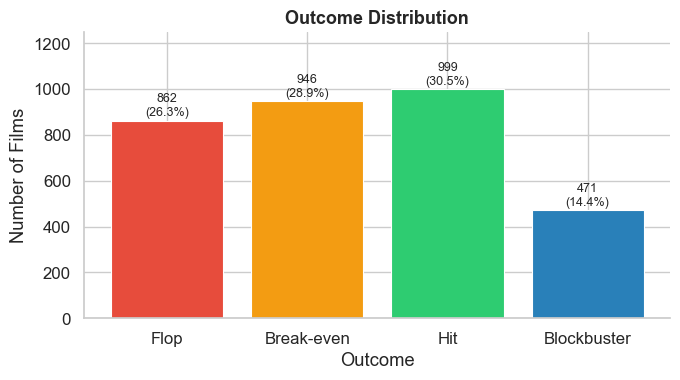

In [76]:
# Plot 1 -- Outcome distribution
fig, ax = plt.subplots(figsize=(7, 4))
counts = df_feat['outcome_label'].value_counts()[outcome_order]
bars = ax.bar(outcome_order, counts.values,
              color=[OUTCOME_COLORS[o] for o in outcome_order],
              edgecolor='white', linewidth=0.8)
for bar, count in zip(bars, counts.values):
    pct = count / len(df_feat) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Outcome Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('Number of Films')
ax.set_ylim(0, counts.max() * 1.25)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

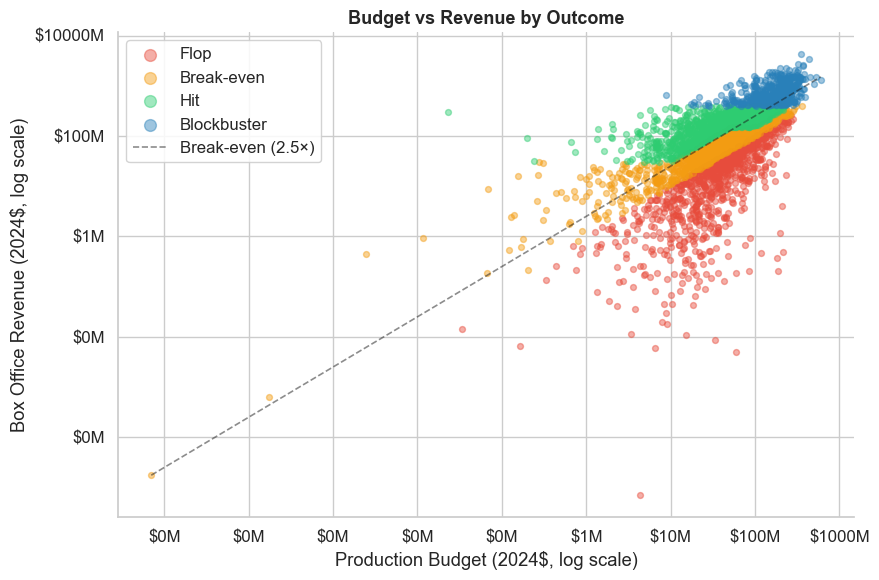

In [77]:
# Plot 2 -- Budget vs Revenue scatter (log scale, coloured by outcome)
fig, ax = plt.subplots(figsize=(9, 6))
for outcome in outcome_order:
    sub = df_feat[df_feat['outcome_label'] == outcome]
    ax.scatter(sub['budget_adj'], sub['revenue_adj'],
               c=OUTCOME_COLORS[outcome], alpha=0.45, s=18, label=outcome, rasterized=True)

# Break-even reference line (revenue = 2.5x budget)
xlim = np.array([df_feat['budget_adj'].min(), df_feat['budget_adj'].max()])
ax.plot(xlim, xlim * 2.5, 'k--', linewidth=1.2, alpha=0.5, label='Break-even (2.5×)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.set_xlabel('Production Budget (2024$, log scale)')
ax.set_ylabel('Box Office Revenue (2024$, log scale)')
ax.set_title('Budget vs Revenue by Outcome', fontsize=13, fontweight='bold')
ax.legend(markerscale=2, framealpha=0.85)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'budget_revenue_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

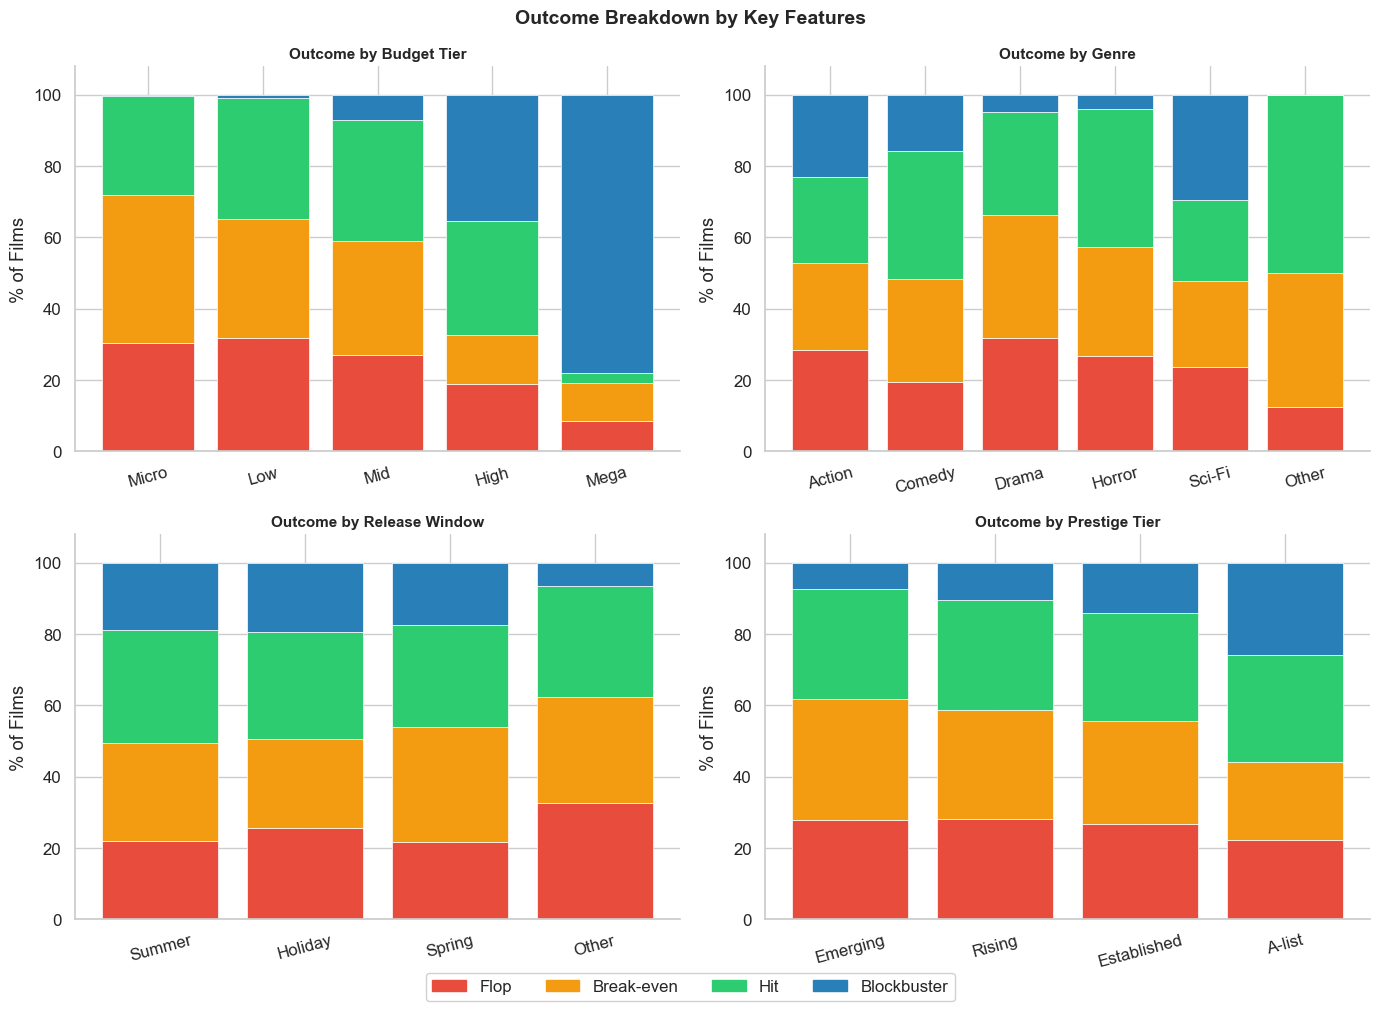

In [78]:
# Plots 3-6 -- Outcome breakdown by budget tier, genre, release window, prestige tier
breakdown_vars = [
    ('budget_tier',    ['Micro', 'Low', 'Mid', 'High', 'Mega'],              'Outcome by Budget Tier'),
    ('genre_bn',       ['Action', 'Comedy', 'Drama', 'Horror', 'Sci-Fi', 'Other'], 'Outcome by Genre'),
    ('release_window', ['Summer', 'Holiday', 'Spring', 'Other'],             'Outcome by Release Window'),
    ('prestige_tier',  ['Emerging', 'Rising', 'Established', 'A-list'],      'Outcome by Prestige Tier'),
]

#Holiday = November + December (Thanksgiving, Christmas, New Year's window)
#Summer = June, July, August (blockbuster season)
#Spring = March, April, May (shoulder season)
#Other = January, February, September, October (the "dump months" — studios typically release weaker films here)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, cat_order, title) in zip(axes.flat, breakdown_vars):
    ct = pd.crosstab(df_feat[col], df_feat['outcome_label'])
    ct = ct.reindex(index=[x for x in cat_order if x in ct.index],
                    columns=outcome_order, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    bottom = np.zeros(len(ct_pct))
    for outcome in outcome_order:
        if outcome in ct_pct.columns:
            ax.bar(ct_pct.index, ct_pct[outcome], bottom=bottom,
                   color=OUTCOME_COLORS[outcome], label=outcome,
                   edgecolor='white', linewidth=0.5)
            bottom += ct_pct[outcome].values
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('% of Films')
    ax.set_ylim(0, 108)
    ax.tick_params(axis='x', rotation=15)
    sns.despine(ax=ax)

handles = [mpatches.Patch(color=OUTCOME_COLORS[o], label=o) for o in outcome_order]
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.02), framealpha=0.9)
plt.suptitle('Outcome Breakdown by Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'outcome_breakdowns.png', dpi=150, bbox_inches='tight')
plt.show()

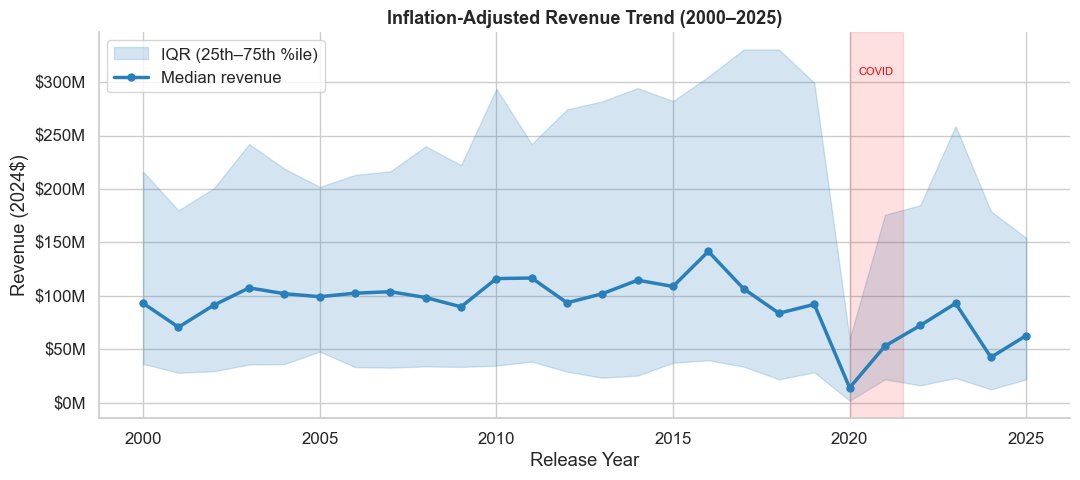

In [79]:
# Plot 7 -- Inflation-adjusted revenue trend 2000-2025
yearly = df_feat.groupby('release_year').agg(
    median_rev=('revenue_adj', 'median'),
    q25_rev=('revenue_adj', lambda x: x.quantile(0.25)),
    q75_rev=('revenue_adj', lambda x: x.quantile(0.75)),
).reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(yearly['release_year'], yearly['q25_rev'] / 1e6, yearly['q75_rev'] / 1e6,
                alpha=0.2, color='#2980b9', label='IQR (25th–75th %ile)')
ax.plot(yearly['release_year'], yearly['median_rev'] / 1e6,
        color='#2980b9', linewidth=2.5, marker='o', markersize=5, label='Median revenue')
ax.axvspan(2020, 2021.5, alpha=0.12, color='red')
ax.text(2020.75, yearly['q75_rev'].max() / 1e6 * 0.93, 'COVID', ha='center', fontsize=8, color='red')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.set_xlabel('Release Year')
ax.set_ylabel('Revenue (2024$)')
ax.set_title('Inflation-Adjusted Revenue Trend (2000–2025)', fontsize=13, fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 - Bayesian Network

In [80]:
# Prepare BN dataset -- select 5 variables, drop NAs, cast to string for pgmpy
BN_COLS = ['prestige_tier', 'genre_bn', 'release_window', 'budget_tier', 'outcome_label']

if 'df_feat' not in dir() or df_feat is None:
    df_feat = pd.read_csv(FEAT_PATH)
    print(f'Loaded {len(df_feat)} rows from {FEAT_PATH}')

df_bn = df_feat[BN_COLS].dropna().astype(str)
print(f'BN dataset: {len(df_bn)} rows × {len(BN_COLS)} variables')
print('\nVariable states:')
for col in BN_COLS:
    states = sorted(df_bn[col].unique())
    print(f'  {col:<20} {states}')

BN dataset: 3278 rows × 5 variables

Variable states:
  prestige_tier        ['A-list', 'Emerging', 'Established', 'Rising']
  genre_bn             ['Action', 'Comedy', 'Drama', 'Horror', 'Other', 'Sci-Fi']
  release_window       ['Holiday', 'Other', 'Spring', 'Summer']
  budget_tier          ['High', 'Low', 'Mega', 'Micro', 'Mid']
  outcome_label        ['Blockbuster', 'Break-even', 'Flop', 'Hit']


In [81]:
# PC algorithm finds statistically supported dependencies (undirected skeleton)
# Domain knowledge then orients every edge causally
BN_COLS = ['prestige_tier', 'genre_bn', 'release_window', 'budget_tier', 'outcome_label']
df_bn = df_feat[BN_COLS].dropna().astype(str)
print(f'BN dataset: {len(df_bn)} rows × {len(BN_COLS)} variables')

pc = PC(df_bn)
skeleton, _ = pc.estimate(
    variant='stable', ci_test='chi_square',
    significance_level=0.05, return_type='skeleton', show_progress=False
)
print('\nPC skeleton edges (undirected):')
for e in sorted(skeleton.edges()):
    print(f'  {e[0]}  --  {e[1]}')

# Domain-knowledge orientation
# prestige → genre/budget choice (A-list actors pick bigger projects)
# genre    → budget commitment, release timing
# release  → budget scale (summer/holiday = bigger spend)
# budget   → outcome (scale drives reach)
HYBRID_EDGES = [
    ('prestige_tier',  'genre_bn'),
    ('prestige_tier',  'budget_tier'),
    ('prestige_tier',  'outcome_label'),
    ('genre_bn',       'budget_tier'),
    ('genre_bn',       'outcome_label'),
    ('genre_bn',       'release_window'),
    ('release_window', 'budget_tier'),
    ('budget_tier',    'outcome_label'),
]
model = DiscreteBayesianNetwork(HYBRID_EDGES)
print('\nHybrid DAG edges (domain-oriented):')
for e in model.edges():
    print(f'  {e[0]}  →  {e[1]}')

BN dataset: 3278 rows × 5 variables

PC skeleton edges (undirected):
  budget_tier  --  outcome_label
  genre_bn  --  budget_tier
  genre_bn  --  outcome_label
  genre_bn  --  release_window
  prestige_tier  --  budget_tier
  prestige_tier  --  genre_bn
  release_window  --  budget_tier
  release_window  --  outcome_label

Hybrid DAG edges (domain-oriented):
  prestige_tier  →  genre_bn
  prestige_tier  →  budget_tier
  prestige_tier  →  outcome_label
  genre_bn  →  budget_tier
  genre_bn  →  outcome_label
  genre_bn  →  release_window
  budget_tier  →  outcome_label
  release_window  →  budget_tier


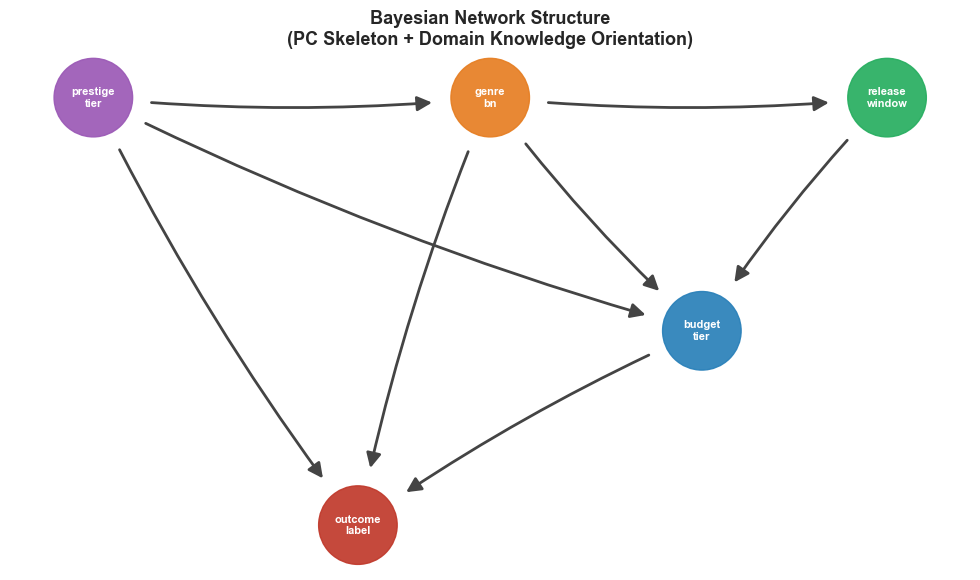

In [82]:
# Visualise the DAG
NODE_COLORS = {
    'prestige_tier':  '#9b59b6',
    'genre_bn':       '#e67e22',
    'release_window': '#27ae60',
    'budget_tier':    '#2980b9',
    'outcome_label':  '#c0392b',
}
pos = {
    'prestige_tier':  (-1.5,  1.0),
    'genre_bn':       ( 0.0,  1.0),
    'release_window': ( 1.5,  1.0),
    'budget_tier':    ( 0.8, -0.2),
    'outcome_label':  (-0.5, -1.2),
}

fig, ax = plt.subplots(figsize=(10, 6))
G = nx.DiGraph(model.edges())
nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=[NODE_COLORS[n] for n in G.nodes()],
    node_size=3200, alpha=0.92)
nx.draw_networkx_labels(G, pos, ax=ax,
    labels={n: n.replace('_', '\n') for n in G.nodes()},
    font_size=8, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax,
    edge_color='#444444', arrows=True, arrowsize=22,
    arrowstyle='-|>', width=2.0,
    connectionstyle='arc3,rad=0.05',
    min_source_margin=42, min_target_margin=42)
ax.set_title('Bayesian Network Structure\n(PC Skeleton + Domain Knowledge Orientation)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'bayesian_network_dag.png', dpi=150, bbox_inches='tight')
plt.show()

In [83]:
# Fit CPDs using Bayesian Estimation with a BDeu (Bayesian Dirichlet equivalent uniform) prior
# equivalent_sample_size=5 adds 5 uniform pseudo-counts spread across all states of each CPD cell
# Weak prior relative to 3,278 samples -- just enough to smooth zero-probability sparse cells
# (e.g. Mega+Horror has very few observations; MLE would give overconfident point estimates)
from pgmpy.estimators import BayesianEstimator

model.fit(df_bn, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=5)
print('CPDs fitted with Bayesian Estimation (BDeu prior, ESS=5).')
print(f'Nodes: {list(model.nodes())}')
print(f'Edges: {list(model.edges())}')

CPDs fitted with Bayesian Estimation (BDeu prior, ESS=5).
Nodes: ['prestige_tier', 'genre_bn', 'budget_tier', 'outcome_label', 'release_window']
Edges: [('prestige_tier', 'genre_bn'), ('prestige_tier', 'budget_tier'), ('prestige_tier', 'outcome_label'), ('genre_bn', 'budget_tier'), ('genre_bn', 'outcome_label'), ('genre_bn', 'release_window'), ('budget_tier', 'outcome_label'), ('release_window', 'budget_tier')]


In [84]:
# Serialize trained model for the Streamlit app
import pickle

MODEL_PATH = DATA_PATH / 'bn_model.pkl'
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model, f)
print(f'Model saved → {MODEL_PATH}')
print(f'File size: {MODEL_PATH.stat().st_size / 1024:.1f} KB')

Model saved → data\bn_model.pkl
File size: 10.4 KB


In [85]:
# Model validation + readable CPD summary
print(f'Model valid: {model.check_model()}')
total_params = sum(cpd.get_values().size for cpd in model.cpds)
print(f'Total parameters: {total_params}')

# Root node -- marginal P(prestige_tier)
print('\n--- P(prestige_tier) ---')
print(model.get_cpds('prestige_tier'))

# P(release_window | genre_bn) -- one parent, compact and readable
print('\n--- P(release_window | genre_bn) ---')
print(model.get_cpds('release_window'))

Model valid: True
Total parameters: 1012

--- P(prestige_tier) ---
+----------------------------+----------+
| prestige_tier(A-list)      | 0.250152 |
+----------------------------+----------+
| prestige_tier(Emerging)    | 0.250152 |
+----------------------------+----------+
| prestige_tier(Established) | 0.249848 |
+----------------------------+----------+
| prestige_tier(Rising)      | 0.249848 |
+----------------------------+----------+

--- P(release_window | genre_bn) ---
+-------------------------+-----+---------------------+
| genre_bn                | ... | genre_bn(Sci-Fi)    |
+-------------------------+-----+---------------------+
| release_window(Holiday) | ... | 0.18254292722812757 |
+-------------------------+-----+---------------------+
| release_window(Other)   | ... | 0.33462796402289446 |
+-------------------------+-----+---------------------+
| release_window(Spring)  | ... | 0.22669664758789862 |
+-------------------------+-----+---------------------+
| release_win

## Section 6 - Probabilistic Inference

In [86]:
# Variable Elimination engine + query helper
infer = VariableElimination(model)

def query_outcome(evidence):
    res    = infer.query(['outcome_label'], evidence=evidence, show_progress=False)
    states = res.state_names['outcome_label']
    return {s: float(v) for s, v in zip(states, res.values)}

print('Variable Elimination engine ready.')

Variable Elimination engine ready.


In [87]:
# Single-variable marginal queries -- isolate effect of each feature
print('=== Prestige Tier Effect ===')
for tier in ['Emerging', 'Rising', 'Established', 'A-list']:
    probs = query_outcome({'prestige_tier': tier})
    bb    = probs.get('Blockbuster', 0)
    flop  = probs.get('Flop', 0)
    print(f'  {tier:<14}  P(Blockbuster)={bb:.3f}  P(Flop)={flop:.3f}')

print('\n=== Budget Tier Effect ===')
for tier in ['Micro', 'Low', 'Mid', 'High', 'Mega']:
    probs = query_outcome({'budget_tier': tier})
    bb    = probs.get('Blockbuster', 0)
    flop  = probs.get('Flop', 0)
    print(f'  {tier:<8}  P(Blockbuster)={bb:.3f}  P(Flop)={flop:.3f}')

print('\n=== Genre Effect ===')
for genre in ['Action', 'Comedy', 'Drama', 'Horror', 'Sci-Fi']:
    probs = query_outcome({'genre_bn': genre})
    bb    = probs.get('Blockbuster', 0)
    flop  = probs.get('Flop', 0)
    print(f'  {genre:<8}  P(Blockbuster)={bb:.3f}  P(Flop)={flop:.3f}')

print('\n=== Release Window Effect ===')
for window in ['Summer', 'Holiday', 'Spring', 'Other']:
    probs = query_outcome({'release_window': window})
    bb    = probs.get('Blockbuster', 0)
    flop  = probs.get('Flop', 0)
    print(f'  {window:<8}  P(Blockbuster)={bb:.3f}  P(Flop)={flop:.3f}')

=== Prestige Tier Effect ===
  Emerging        P(Blockbuster)=0.078  P(Flop)=0.277
  Rising          P(Blockbuster)=0.103  P(Flop)=0.282
  Established     P(Blockbuster)=0.142  P(Flop)=0.268
  A-list          P(Blockbuster)=0.249  P(Flop)=0.228

=== Budget Tier Effect ===
  Micro     P(Blockbuster)=0.003  P(Flop)=0.304
  Low       P(Blockbuster)=0.010  P(Flop)=0.319
  Mid       P(Blockbuster)=0.071  P(Flop)=0.272
  High      P(Blockbuster)=0.351  P(Flop)=0.190
  Mega      P(Blockbuster)=0.777  P(Flop)=0.087

=== Genre Effect ===
  Action    P(Blockbuster)=0.226  P(Flop)=0.286
  Comedy    P(Blockbuster)=0.158  P(Flop)=0.194
  Drama     P(Blockbuster)=0.049  P(Flop)=0.318
  Horror    P(Blockbuster)=0.040  P(Flop)=0.268
  Sci-Fi    P(Blockbuster)=0.291  P(Flop)=0.238

=== Release Window Effect ===
  Summer    P(Blockbuster)=0.183  P(Flop)=0.246
  Holiday   P(Blockbuster)=0.173  P(Flop)=0.260
  Spring    P(Blockbuster)=0.162  P(Flop)=0.252
  Other     P(Blockbuster)=0.086  P(Flop)=0.286


In [88]:
# Business-relevant multi-variable scenario queries
scenarios = [
    ('A-list + Mega',                  {'prestige_tier': 'A-list',     'budget_tier': 'Mega'}),
    ('A-list + Action + Summer',       {'prestige_tier': 'A-list',     'genre_bn': 'Action',  'release_window': 'Summer'}),
    ('A-list + Action + Mega + Summer',{'prestige_tier': 'A-list',     'genre_bn': 'Action',  'budget_tier': 'Mega',  'release_window': 'Summer'}),
    ('Emerging + Drama + Low + Other', {'prestige_tier': 'Emerging',   'genre_bn': 'Drama',   'budget_tier': 'Low',   'release_window': 'Other'}),
    ('Emerging + Micro',               {'prestige_tier': 'Emerging',   'budget_tier': 'Micro'}),
    ('Established + Horror + Holiday', {'prestige_tier': 'Established','genre_bn': 'Horror',  'release_window': 'Holiday'}),
]

print('=== Multi-Variable Scenario Analysis ===')
for label, evidence in scenarios:
    probs = query_outcome(evidence)
    print(f'\n{label}')
    for outcome in outcome_order:
        bar = '█' * int(probs.get(outcome, 0) * 25)
        print(f'  {outcome:<12} {probs.get(outcome, 0):.3f}  {bar}')
    print(f'  → MAP: {max(probs, key=probs.get)}')

# MAP query for the "ideal blockbuster" profile
map_result = infer.map_query(
    ['outcome_label'],
    evidence={'prestige_tier': 'A-list', 'genre_bn': 'Action',
              'budget_tier': 'Mega',     'release_window': 'Summer'},
    show_progress=False
)
print(f'\nMAP prediction (A-list + Action + Mega + Summer): {map_result["outcome_label"]}')

=== Multi-Variable Scenario Analysis ===

A-list + Mega
  Flop         0.075  █
  Break-even   0.051  █
  Hit          0.035  
  Blockbuster  0.839  ████████████████████
  → MAP: Blockbuster

A-list + Action + Summer
  Flop         0.168  ████
  Break-even   0.148  ███
  Hit          0.246  ██████
  Blockbuster  0.439  ██████████
  → MAP: Blockbuster

A-list + Action + Mega + Summer
  Flop         0.060  █
  Break-even   0.036  
  Hit          0.024  
  Blockbuster  0.881  ██████████████████████
  → MAP: Blockbuster

Emerging + Drama + Low + Other
  Flop         0.352  ████████
  Break-even   0.296  ███████
  Hit          0.352  ████████
  Blockbuster  0.000  
  → MAP: Flop

Emerging + Micro
  Flop         0.290  ███████
  Break-even   0.424  ██████████
  Hit          0.281  ███████
  Blockbuster  0.005  
  → MAP: Break-even

Established + Horror + Holiday
  Flop         0.297  ███████
  Break-even   0.208  █████
  Hit          0.473  ███████████
  Blockbuster  0.022  
  → MAP: Hit

MA

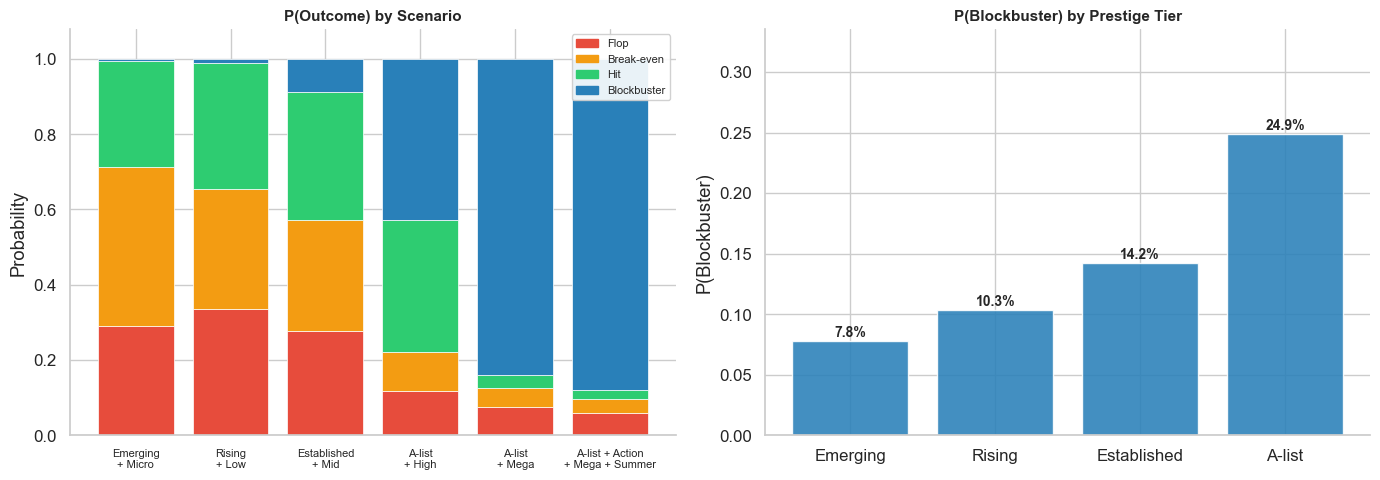

In [89]:
# Inference visualisation
scenarios_viz = {
    'Emerging\n+ Micro':                {'prestige_tier': 'Emerging',    'budget_tier': 'Micro'},
    'Rising\n+ Low':                    {'prestige_tier': 'Rising',      'budget_tier': 'Low'},
    'Established\n+ Mid':               {'prestige_tier': 'Established', 'budget_tier': 'Mid'},
    'A-list\n+ High':                   {'prestige_tier': 'A-list',      'budget_tier': 'High'},
    'A-list\n+ Mega':                   {'prestige_tier': 'A-list',      'budget_tier': 'Mega'},
    'A-list + Action\n+ Mega + Summer': {'prestige_tier': 'A-list',      'genre_bn': 'Action',
                                         'budget_tier': 'Mega',          'release_window': 'Summer'},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full stacked outcome probability per scenario
labels = list(scenarios_viz.keys())
data = {o: [] for o in outcome_order}
for ev in scenarios_viz.values():
    probs = query_outcome(ev)
    for o in outcome_order:
        data[o].append(probs.get(o, 0))

bottom = np.zeros(len(labels))
for outcome in outcome_order:
    axes[0].bar(labels, data[outcome], bottom=bottom,
                color=OUTCOME_COLORS[outcome], label=outcome, edgecolor='white', linewidth=0.5)
    bottom += np.array(data[outcome])
axes[0].set_title('P(Outcome) by Scenario', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Probability')
axes[0].set_ylim(0, 1.08)
axes[0].tick_params(axis='x', labelsize=8)
handles = [mpatches.Patch(color=OUTCOME_COLORS[o], label=o) for o in outcome_order]
axes[0].legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9)
sns.despine(ax=axes[0])

# Right: P(Blockbuster) by prestige tier
tiers    = ['Emerging', 'Rising', 'Established', 'A-list']
bb_probs = [query_outcome({'prestige_tier': t}).get('Blockbuster', 0) for t in tiers]
bars = axes[1].bar(tiers, bb_probs,
                   color=OUTCOME_COLORS['Blockbuster'], edgecolor='white', alpha=0.88)
for bar, p in zip(bars, bb_probs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                 f'{p:.1%}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('P(Blockbuster) by Prestige Tier', fontsize=11, fontweight='bold')
axes[1].set_ylabel('P(Blockbuster)')
axes[1].set_ylim(0, max(bb_probs) * 1.35)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'inference_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 - Two-Layer Modeling

This section separates the notebook into two jobs on purpose.

### Layer 1 - Bayesian Network as the explanation engine

The Bayesian Network keeps the original four outcome classes:

- `Flop`
- `Break-even`
- `Hit`
- `Blockbuster`

It only uses four interpretable pre-release features:

- `budget_tier`
- `genre_bn`
- `prestige_tier`
- `release_window`

That makes it useful for probability reasoning and scenario analysis, but it also caps hard-label accuracy because many films share the same four-category profile while ending up in different commercial tiers.

### Layer 2 - Gradient Boosting as the prediction engine

For pure prediction, we switch to a binary target:

- `Blockbuster`
- `Not Blockbuster`

The Gradient Boosting model uses stronger signals already available in the repo, including exact adjusted budget, release year, runtime, full genre information, prestige, timing, and TMDb engagement variables. This is intentionally a different task from the BN: the goal here is **better blockbuster detection**, not four-class interpretability.


In [90]:
# Layer 1: Explanation engine benchmark on the original 4-class task

BN_COLS      = ['prestige_tier', 'genre_bn', 'release_window', 'budget_tier', 'outcome_label']
feature_cols = ['prestige_tier', 'genre_bn', 'release_window', 'budget_tier']

df_ml = df_feat[BN_COLS].dropna().reset_index(drop=True).copy()
df_ml['outcome_label'] = df_ml['outcome_label'].astype(str)

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X   = enc.fit_transform(df_ml[feature_cols])
y   = df_ml['outcome_label'].values

idx_train, idx_test = train_test_split(
    np.arange(len(df_ml)), test_size=0.2, random_state=42, stratify=y
)
X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]
df_test_bn = df_ml.iloc[idx_test][feature_cols].reset_index(drop=True)

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
print('Test class distribution:')
for label in outcome_order:
    count = (y_test == label).sum()
    print(f'  {label:<12} {count:>4}  ({count/len(y_test)*100:.1f}%)')

# Simple baselines on the exact same 4-feature / 4-class task
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# BN predictions via posterior lookup over all evidence combinations
from itertools import product as iproduct

prestige_states = sorted(df_bn['prestige_tier'].unique())
genre_states    = sorted(df_bn['genre_bn'].unique())
window_states   = sorted(df_bn['release_window'].unique())
budget_states   = sorted(df_bn['budget_tier'].unique())

n_combos = len(prestige_states) * len(genre_states) * len(window_states) * len(budget_states)
print()
print(f'Precomputing BN posteriors for {n_combos} unique evidence combinations...')

posterior_lookup = {}
map_lookup = {}
top2_lookup = {}
for p, g, w, b in tqdm(iproduct(prestige_states, genre_states, window_states, budget_states), total=n_combos):
    ev = {'prestige_tier': p, 'genre_bn': g, 'release_window': w, 'budget_tier': b}
    key = (p, g, w, b)
    try:
        q = infer.query(['outcome_label'], evidence=ev, show_progress=False)
        probs = pd.Series(q.values, index=q.state_names['outcome_label']).sort_values(ascending=False)
        posterior_lookup[key] = probs.to_dict()
        map_lookup[key] = probs.index[0]
        top2_lookup[key] = set(probs.index[:2])
    except Exception:
        fallback = {'Break-even': 1.0}
        posterior_lookup[key] = fallback
        map_lookup[key] = 'Break-even'
        top2_lookup[key] = {'Break-even'}

y_pred_bn = np.array([
    map_lookup.get((row['prestige_tier'], row['genre_bn'], row['release_window'], row['budget_tier']), 'Break-even')
    for _, row in df_test_bn.iterrows()
])

bn_top2_hits = []
for truth, (_, row) in zip(y_test, df_test_bn.iterrows()):
    key = (row['prestige_tier'], row['genre_bn'], row['release_window'], row['budget_tier'])
    bn_top2_hits.append(truth in top2_lookup.get(key, {'Break-even'}))
bn_top2_acc = float(np.mean(bn_top2_hits))

print(f'LR  accuracy: {accuracy_score(y_test, y_pred_lr):.3f}')
print(f'RF  accuracy: {accuracy_score(y_test, y_pred_rf):.3f}')
print(f'BN  accuracy: {accuracy_score(y_test, y_pred_bn):.3f}')
print(f'BN top-2 accuracy: {bn_top2_acc:.3f}')


Train: 2622  |  Test: 656
Test class distribution:
  Flop          173  (26.4%)
  Break-even    189  (28.8%)
  Hit           200  (30.5%)
  Blockbuster    94  (14.3%)

Precomputing BN posteriors for 480 unique evidence combinations...


  0%|          | 0/480 [00:00<?, ?it/s]

LR  accuracy: 0.305
RF  accuracy: 0.384
BN  accuracy: 0.451
BN top-2 accuracy: 0.748


### Reading the BN honestly

The Bayesian Network is the **explanation engine**, not the notebook's strongest hard-label classifier.

Its roughly `45%` four-class accuracy should be interpreted carefully:

- the model only sees **four coarse categorical inputs**
- many films share the same four-feature profile but land in different outcome tiers
- the target itself is deliberately hard because it mixes **absolute revenue scale** with **ROI efficiency**
- a hard miss can still be a reasonable probabilistic read if the true class sits inside the model's high-probability middle band

So the right question is not "does the BN perfectly classify every film?" It is:

> **Does the BN reveal how budget, genre, prestige, and timing shift the probability distribution across the four outcomes?**

That is why we keep it for inference, sensitivity analysis, and strategic storytelling even though we use a different model for stronger blockbuster prediction.


In [91]:
# Layer 2: Gradient Boosting prediction engine for Blockbuster vs Not Blockbuster

class GenreMultiHot(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        series = pd.Series(np.asarray(X).ravel()).fillna('')
        genre_lists = [[g.strip() for g in item.split('|') if g.strip()] for item in series]
        self.mlb_ = MultiLabelBinarizer().fit(genre_lists)
        return self

    def transform(self, X):
        series = pd.Series(np.asarray(X).ravel()).fillna('')
        genre_lists = [[g.strip() for g in item.split('|') if g.strip()] for item in series]
        return self.mlb_.transform(genre_lists)

    def get_feature_names_out(self, input_features=None):
        return np.array([f'genre::{genre}' for genre in self.mlb_.classes_], dtype=object)

PRED_FEATURES = [
    'genres', 'prestige_tier', 'release_window', 'budget_adj',
    'release_year', 'runtime', 'popularity', 'vote_average', 'vote_count'
]
CAT_FEATURES = ['prestige_tier', 'release_window']
NUM_FEATURES = ['budget_adj', 'release_year', 'runtime', 'popularity', 'vote_average', 'vote_count']

# Binary target for the prediction layer
# This model is broader than the BN and intentionally uses stronger repo-level signals.
df_pred = df_feat[PRED_FEATURES + ['outcome_label']].dropna().reset_index(drop=True).copy()
df_pred['is_blockbuster'] = (df_pred['outcome_label'] == 'Blockbuster').astype(int)

X_pred = df_pred[PRED_FEATURES]
y_pred_bin = df_pred['is_blockbuster'].values
X_train_pred = X_pred.iloc[idx_train].reset_index(drop=True)
X_test_pred  = X_pred.iloc[idx_test].reset_index(drop=True)
y_train_pred = y_pred_bin[idx_train]
y_test_pred  = y_pred_bin[idx_test]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_FEATURES),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), NUM_FEATURES),
        ('genres', GenreMultiHot(), ['genres']),
    ],
    remainder='drop',
    sparse_threshold=0,
)

gb = GradientBoostingClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.04,
    max_depth=3,
)

gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', gb),
])

gb_pipe.fit(X_train_pred, y_train_pred)
gb_proba = gb_pipe.predict_proba(X_test_pred)[:, 1]
gb_pred  = (gb_proba >= 0.5).astype(int)

binary_results = pd.DataFrame([
    {
        'Model': 'Gradient Boosting (Blockbuster vs Not)',
        'Accuracy': accuracy_score(y_test_pred, gb_pred),
        'Precision': precision_score(y_test_pred, gb_pred, zero_division=0),
        'Recall': recall_score(y_test_pred, gb_pred, zero_division=0),
        'F1': f1_score(y_test_pred, gb_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_test_pred, gb_proba),
    }
])

print('Blockbuster prevalence in test set:', f'{y_test_pred.mean():.1%}')
print(binary_results.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print()
print('Classification report:')
print(classification_report(y_test_pred, gb_pred, target_names=['Not Blockbuster', 'Blockbuster'], zero_division=0))

feature_names = gb_pipe.named_steps['preprocessor'].get_feature_names_out()
feature_importance = (
    pd.DataFrame({'feature': feature_names, 'importance': gb_pipe.named_steps['model'].feature_importances_})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
feature_importance.head(12)


Blockbuster prevalence in test set: 14.3%
                                 Model  Accuracy  Precision  Recall    F1  ROC AUC
Gradient Boosting (Blockbuster vs Not)     0.939      0.821   0.734 0.775    0.969

Classification report:
                 precision    recall  f1-score   support

Not Blockbuster       0.96      0.97      0.96       562
    Blockbuster       0.82      0.73      0.78        94

       accuracy                           0.94       656
      macro avg       0.89      0.85      0.87       656
   weighted avg       0.94      0.94      0.94       656



,feature,importance
0,num__budget_adj,0.544517
1,num__vote_count,0.258571
2,num__popularity,0.131113
3,num__vote_average,0.019240
4,genres__genre::Animation,0.009590
5,num__runtime,0.009464
6,num__release_year,0.005718
7,genres__genre::Western,0.005566
8,cat__release_window_Other,0.002574
9,genres__genre::Family,0.002178


In [92]:
# Save GB pipeline + inference metadata for the Streamlit app
import pickle, json
from pathlib import Path

with open(Path('data') / 'gb_model.pkl', 'wb') as f:
    pickle.dump(gb_pipe, f)

gb_meta = {
    'runtime':      float(X_train_pred['runtime'].median()),
    'popularity':   float(X_train_pred['popularity'].median()),
    'vote_average': float(X_train_pred['vote_average'].median()),
    'vote_count':   float(X_train_pred['vote_count'].median()),
    'release_year': 2025,
    'tier_budget_adj': (
        df_feat.groupby('budget_tier')['budget_adj']
        .median()
        .fillna(df_feat['budget_adj'].median())
        .to_dict()
    ),
}

with open(Path('data') / 'gb_meta.json', 'w') as f:
    json.dump(gb_meta, f, indent=2)

print('Saved data/gb_model.pkl')
print('Saved data/gb_meta.json')
print('Tier budgets:', {k: f'${v/1e6:.0f}M' for k, v in gb_meta['tier_budget_adj'].items()})


Saved data/gb_model.pkl
Saved data/gb_meta.json
Tier budgets: {'Micro': '$5M', 'Low': '$24M', 'Mid': '$60M', 'High': '$133M', 'Mega': '$238M'}


              Model  Accuracy  F1 (macro)  F1 (weighted)
   Bayesian Network     0.451       0.466          0.443
Logistic Regression     0.305       0.270          0.286
      Random Forest     0.384       0.400          0.374


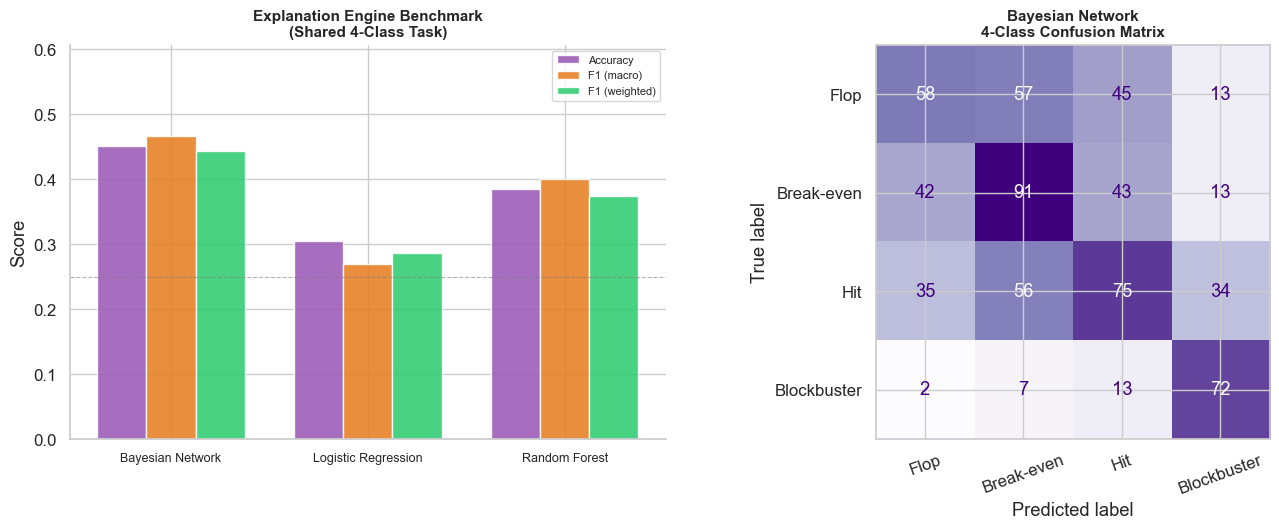

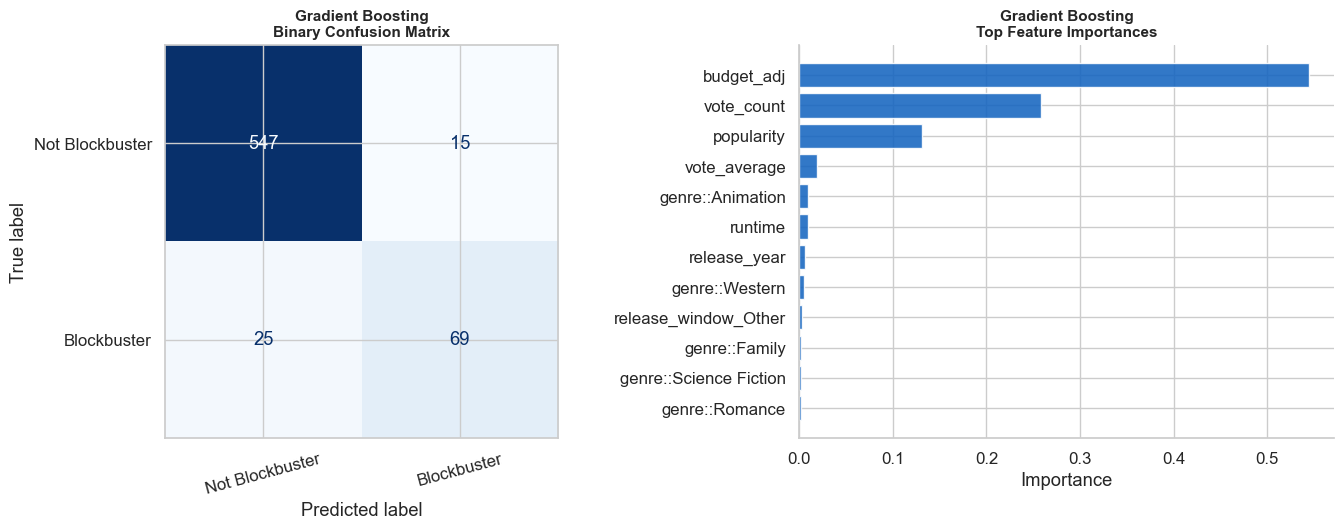

In [93]:
# Visual diagnostics for both layers

def model_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1 (macro)': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 (weighted)': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

explanation_results = pd.DataFrame([
    model_metrics(y_test, y_pred_bn, 'Bayesian Network'),
    model_metrics(y_test, y_pred_lr, 'Logistic Regression'),
    model_metrics(y_test, y_pred_rf, 'Random Forest'),
])
print(explanation_results.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
metric_cols = ['Accuracy', 'F1 (macro)', 'F1 (weighted)']
x = np.arange(len(explanation_results))
width = 0.25
pal = ['#9b59b6', '#e67e22', '#2ecc71']

for i, (col, color) in enumerate(zip(metric_cols, pal)):
    axes[0].bar(x + (i - 1) * width, explanation_results[col], width,
                label=col, color=color, alpha=0.88, edgecolor='white')
axes[0].axhline(0.25, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(explanation_results['Model'], fontsize=9)
axes[0].set_ylim(0, min(explanation_results[metric_cols].max().max() * 1.3, 1.0))
axes[0].set_title('Explanation Engine Benchmark' + chr(10) + '(Shared 4-Class Task)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=8)
sns.despine(ax=axes[0])

cm_bn = confusion_matrix(y_test, y_pred_bn, labels=outcome_order)
ConfusionMatrixDisplay(cm_bn, display_labels=outcome_order).plot(
    ax=axes[1], colorbar=False, cmap='Purples'
)
axes[1].set_title('Bayesian Network' + chr(10) + '4-Class Confusion Matrix', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
cm_gb = confusion_matrix(y_test_pred, gb_pred)
ConfusionMatrixDisplay(cm_gb, display_labels=['Not Blockbuster', 'Blockbuster']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Gradient Boosting' + chr(10) + 'Binary Confusion Matrix', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

show_top = feature_importance.head(12).sort_values('importance')
axes[1].barh(show_top['feature'].str.replace('cat__', '', regex=False)
                           .str.replace('num__', '', regex=False)
                           .str.replace('genres__', '', regex=False),
             show_top['importance'], color='#1565c0', edgecolor='white', alpha=0.88)
axes[1].set_title('Gradient Boosting' + chr(10) + 'Top Feature Importances', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Importance')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### Reading the Gradient Boosting Results

The model is trained on a richer feature set than the Bayesian Network — nine input variables instead of four — and targets a binary outcome: **Blockbuster vs. Not Blockbuster**.

---

#### Model Performance

| Metric | Score | What it means |
|---|---|---|
| **Accuracy** | 93.9% | Correctly classifies 94 in every 100 films |
| **Precision** | 82.1% | When the model calls a film a Blockbuster, it is right 82% of the time |
| **Recall** | 73.4% | The model catches 73% of all actual Blockbusters |
| **F1** | 0.775 | Harmonic mean of precision and recall — strong for a 14% minority class |
| **ROC AUC** | 0.969 | Near-perfect separation of the two classes across all classification thresholds |

The gap between precision and recall is expected: Blockbusters are rare (14.3% of the test set), so the model is conservative — it only fires when it is confident, which keeps precision high but lets a few true Blockbusters slip through as false negatives.

---

#### What Each Feature Measures

| Feature | What it captures | GB Importance |
|---|---|---|
| `budget_adj` | Inflation-adjusted production budget | **54.5%** |
| `vote_count` | Number of TMDB user ratings — proxy for audience reach and word-of-mouth | **25.9%** |
| `popularity` | TMDB composite engagement score (page views, watchlist adds, social signals) | **13.1%** |
| `vote_average` | Mean TMDB user rating — a quality signal | 1.9% |
| `genre::Animation` | Binary flag: is the film animated? | 1.0% |
| `runtime` | Film length in minutes | 0.9% |
| `release_year` | Calendar year of release | 0.6% |
| `genre::Western` | Binary flag: is the film a Western? | 0.6% |
| `release_window_Other` | Released outside the main summer or holiday windows | 0.3% |
| `genre::Family` | Family genre flag | 0.2% |
| `genre::Science Fiction` | Sci-Fi genre flag | 0.2% |
| `genre::Romance` | Romance genre flag | 0.2% |

---

#### What the Hierarchy Tells Us

**Budget dominates (54.5%).** Studios only commit mega-budgets to films they expect to perform, and those budgets buy the marketing reach that drives box office. It is simultaneously a greenlight signal and a causal lever.

**Audience scale matters more than quality.** Vote count (25.9%) and popularity (13.1%) together outweigh vote average (1.9%) by a factor of 20x. Being seen and talked about predicts commercial success far better than being rated highly.

**Genre is a weak marginal signal.** No individual genre flag crosses 1% importance. Animation and Family flags appear because those genres reliably draw large audiences, but they matter far less than budget or audience engagement scale.

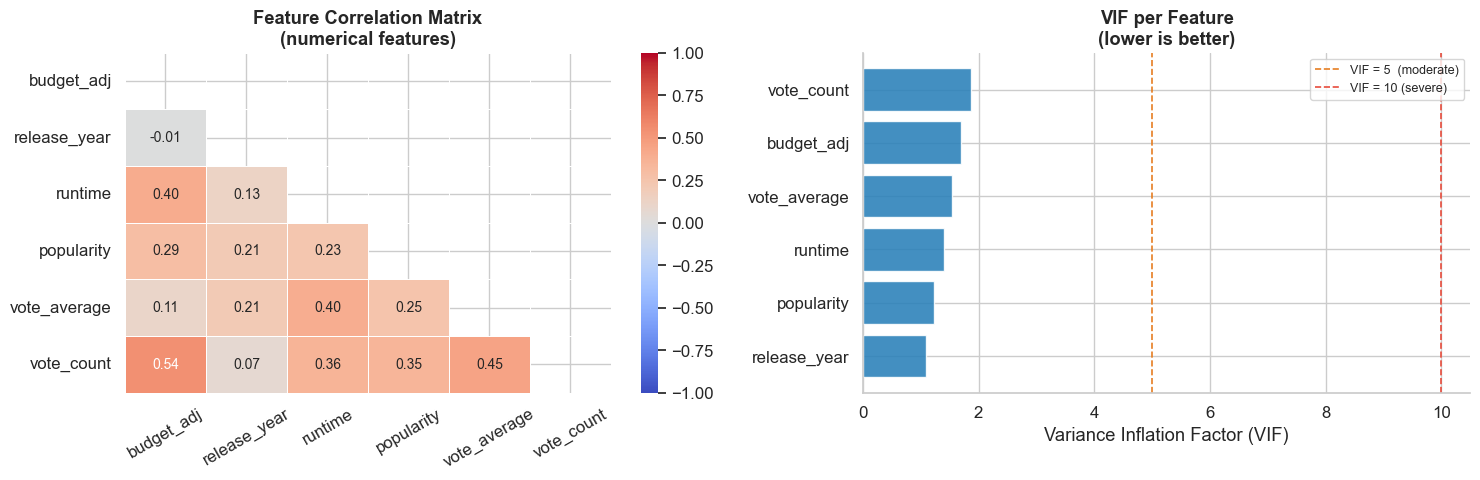

     Feature  VIF
  vote_count 1.87
  budget_adj 1.70
vote_average 1.54
     runtime 1.41
  popularity 1.23
release_year 1.09


In [94]:
# Multicollinearity check on the numerical features
# Before PCA we verify which features are linearly correlated with each other.
from sklearn.linear_model import LinearRegression

# --- Correlation matrix ---
corr = X_train_pred[NUM_FEATURES].corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={'size': 10}, ax=axes[0]
)
axes[0].set_title('Feature Correlation Matrix\n(numerical features)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# --- VIF (Variance Inflation Factor) ---
# VIF_i = 1 / (1 - R²_i), where R²_i comes from regressing feature i on all others.
# VIF > 5 is moderate multicollinearity; VIF > 10 is severe.
vif_rows = []
X_num = X_train_pred[NUM_FEATURES].dropna()
for col in NUM_FEATURES:
    y_col    = X_num[col].values
    X_others = X_num.drop(columns=[col]).values
    r2  = LinearRegression().fit(X_others, y_col).score(X_others, y_col)
    vif = 1 / (1 - r2) if r2 < 1.0 else float('inf')
    vif_rows.append({'Feature': col, 'VIF': round(vif, 2)})

vif_df = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False).reset_index(drop=True)

# VIF bar chart
colors = ['#e74c3c' if v > 10 else '#e67e22' if v > 5 else '#2980b9'
          for v in vif_df['VIF']]
axes[1].barh(vif_df['Feature'][::-1], vif_df['VIF'][::-1],
             color=colors[::-1], edgecolor='white', alpha=0.88)
axes[1].axvline(5,  color='#e67e22', linestyle='--', lw=1.2, label='VIF = 5  (moderate)')
axes[1].axvline(10, color='#e74c3c', linestyle='--', lw=1.2, label='VIF = 10 (severe)')
axes[1].set_xlabel('Variance Inflation Factor (VIF)')
axes[1].set_title('VIF per Feature\n(lower is better)', fontweight='bold')
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'multicollinearity.png', dpi=150, bbox_inches='tight')
plt.show()

print(vif_df.to_string(index=False))


#### Reading the Multicollinearity Results

**All VIF scores are below 2** — well under the moderate threshold of 5. There is no meaningful multicollinearity among the numerical features. Each variable contributes genuinely independent information to the model.

| VIF range | Interpretation |
|---|---|
| < 5 | Low — safe to keep as-is |
| 5 – 10 | Moderate — monitor but usually acceptable |
| > 10 | Severe — feature is nearly redundant with others |

The highest correlation in the matrix is **`budget_adj` × `vote_count` = 0.54** — a moderate positive link (bigger-budget films tend to attract more ratings), but far from problematic. All other pairs are below 0.45.

**What this tells us before PCA:** because the features are largely independent, PCA will need relatively many components to capture most of the variance — the redundancy that PCA thrives on simply is not there. We expect the scree plot to decay gradually rather than drop sharply after the first few components.

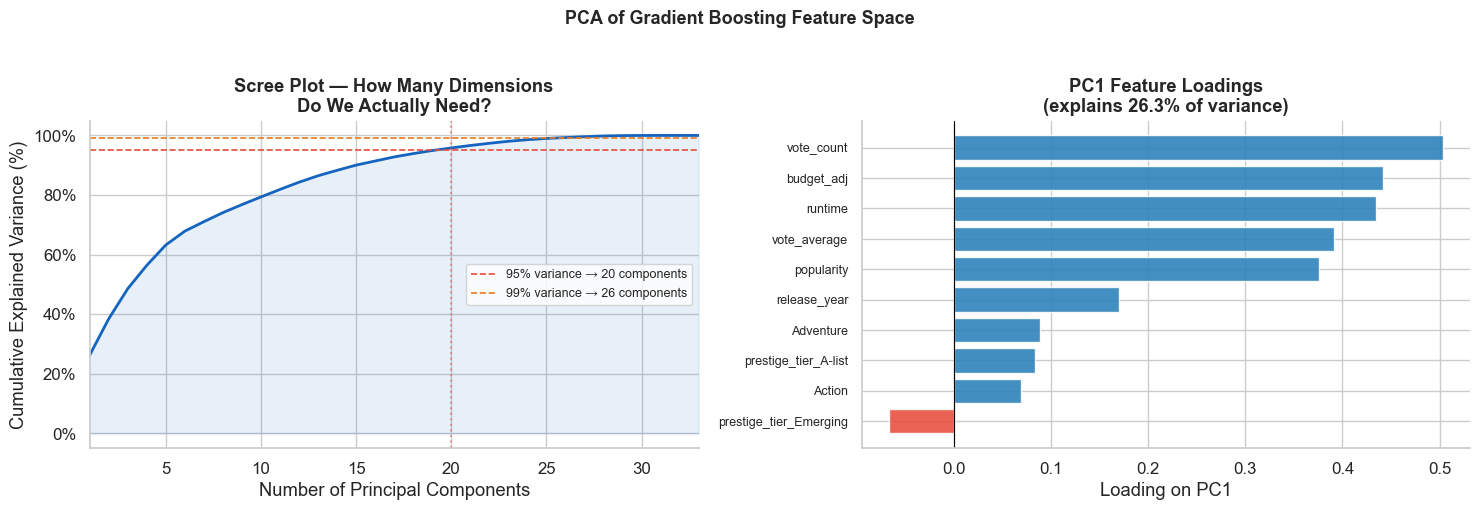

Total features after preprocessing : 33
Components for 95% variance        : 20  (61% of features)
Components for 99% variance        : 26  (79% of features)

PC1 explains 26.3% of variance
PC2 explains 12.2% of variance
PC3 explains 10.1% of variance


In [95]:
# PCA on the Gradient Boosting feature space
# Answers: how many independent dimensions actually drive blockbuster prediction?
from sklearn.decomposition import PCA
import matplotlib.ticker as mticker

# Extract the preprocessed feature matrix (all pipeline steps before the classifier)
X_train_transformed = gb_pipe.named_steps['preprocessor'].transform(X_train_pred)
feature_names_out   = gb_pipe.named_steps['preprocessor'].get_feature_names_out()
clean_names = (
    pd.Series(feature_names_out)
    .str.replace('num__',          '', regex=False)
    .str.replace('cat__',          '', regex=False)
    .str.replace('genres__genre::', '', regex=False)
    .values
)

pca    = PCA(random_state=42).fit(X_train_transformed)
cumvar = np.cumsum(pca.explained_variance_ratio_)
n95    = int(np.searchsorted(cumvar, 0.95)) + 1
n99    = int(np.searchsorted(cumvar, 0.99)) + 1

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot — cumulative explained variance
ax = axes[0]
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, color='#1565c0', lw=2)
ax.fill_between(range(1, len(cumvar) + 1), cumvar * 100, alpha=0.1, color='#1565c0')
ax.axhline(95, color='#e74c3c', linestyle='--', lw=1.2,
           label=f'95% variance \u2192 {n95} components')
ax.axhline(99, color='#e67e22', linestyle='--', lw=1.2,
           label=f'99% variance \u2192 {n99} components')
ax.axvline(n95, color='#e74c3c', linestyle=':', alpha=0.5)
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Scree Plot \u2014 How Many Dimensions\nDo We Actually Need?', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)
ax.set_xlim(1, len(cumvar))
sns.despine(ax=ax)

# PC1 top-10 feature loadings
ax2 = axes[1]
loadings_pc1 = pca.components_[0]
top_n   = 10
top_idx = np.argsort(np.abs(loadings_pc1))[-top_n:]
top_idx = top_idx[np.argsort(loadings_pc1[top_idx])]
top_vals   = loadings_pc1[top_idx]
top_labels = clean_names[top_idx]
bar_colors = ['#2980b9' if v > 0 else '#e74c3c' for v in top_vals]

ax2.barh(range(top_n), top_vals, color=bar_colors, edgecolor='white', alpha=0.88)
ax2.set_yticks(range(top_n))
ax2.set_yticklabels(top_labels, fontsize=9)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_xlabel('Loading on PC1')
ax2.set_title(
    f'PC1 Feature Loadings\n(explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance)',
    fontweight='bold'
)
sns.despine(ax=ax2)

plt.suptitle('PCA of Gradient Boosting Feature Space', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

n_features = X_train_transformed.shape[1]
print(f'Total features after preprocessing : {n_features}')
print(f'Components for 95% variance        : {n95}  ({n95/n_features*100:.0f}% of features)')
print(f'Components for 99% variance        : {n99}  ({n99/n_features*100:.0f}% of features)')
print(f'\nPC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance')
print(f'PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}% of variance')
print(f'PC3 explains {pca.explained_variance_ratio_[2]*100:.1f}% of variance')

#### Reading the PCA Results

The preprocessed feature space has **33 dimensions** after one-hot encoding categorical variables and expanding genre flags.

| Threshold | Components needed | % of original features |
|---|---|---|
| 95% variance | **20 components** | 61% |
| 99% variance | **26 components** | 79% |

**PC1 explains 26.3%** of total variance, PC2 12.2%, PC3 10.1%. The first component is a *scale axis* — its top loadings are `vote_count` (0.50), `budget_adj` (0.44), `runtime` (0.43), `vote_average` (0.38), and `popularity` (0.35). PC1 separates large, widely-seen films from small niche ones.

**Key takeaway:** the scree curve decays gradually — there is no sharp elbow after 2 or 3 components. This is consistent with the low multicollinearity we saw above: independent features spread variance across many dimensions rather than concentrating it. PCA can compress the space from 33 → 20 dimensions while retaining 95% of information, but it cannot compress it to just 3–5 components without significant loss. Section 8 tests whether this compression actually hurts blockbuster prediction.

## Section 8 — PCA Component Sensitivity

The scree plot showed we need **20 components** to retain 95% of the feature variance and **26** for 99%. But variance retention is not the same as prediction quality. This section trains the Gradient Boosting model with progressively fewer PCA components and measures the impact on blockbuster detection performance (Accuracy, Precision, Recall, F1, ROC AUC).

If the model holds up well with 20 components, it confirms the bottom 13 dimensions are noise. If performance drops sharply below 20, those extra components were carrying real signal.

            Label  Accuracy  Precision  Recall    F1  ROC AUC
            5 PCs     0.939      0.829   0.723 0.773    0.958
           10 PCs     0.938      0.827   0.713 0.766    0.956
           15 PCs     0.938      0.827   0.713 0.766    0.958
20 PCs\n(95% var)     0.931      0.810   0.681 0.740    0.958
26 PCs\n(99% var)     0.933      0.829   0.670 0.741    0.958
 Full\n(33 feats)     0.939      0.821   0.734 0.775    0.969


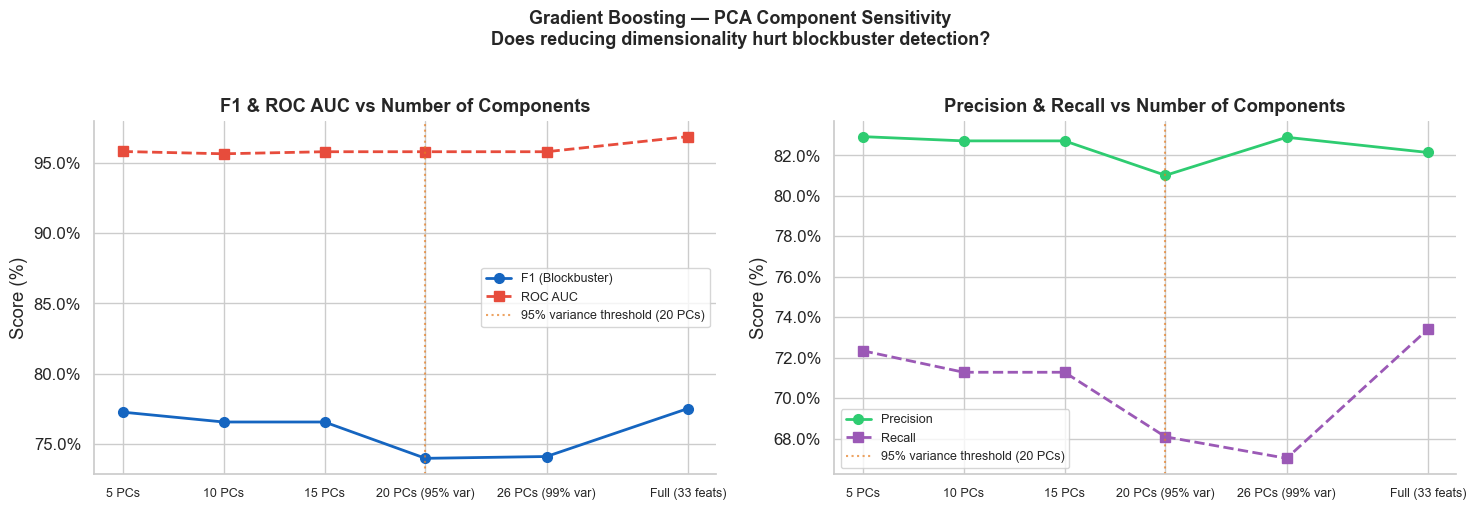

In [96]:
# PCA component sensitivity: train GB with k PCA components, measure blockbuster detection
import matplotlib.ticker as mticker
from sklearn.decomposition import PCA

pca_configs = [
    (5,    '5 PCs'),
    (10,   '10 PCs'),
    (15,   '15 PCs'),
    (20,   '20 PCs\n(95% var)'),
    (26,   '26 PCs\n(99% var)'),
    (None, 'Full\n(33 feats)'),
]

pca_rows = []
for n, label in pca_configs:
    if n is None:
        pipe_eval = gb_pipe
    else:
        pipe_eval = Pipeline([
            ('preprocessor', gb_pipe.named_steps['preprocessor']),
            ('pca', PCA(n_components=n, random_state=42)),
            ('model', GradientBoostingClassifier(
                random_state=42, n_estimators=200,
                learning_rate=0.04, max_depth=3,
            )),
        ])
        pipe_eval.fit(X_train_pred, y_train_pred)
    proba = pipe_eval.predict_proba(X_test_pred)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    pca_rows.append({
        'n':        n if n else 33,
        'Label':    label,
        'Accuracy':  accuracy_score(y_test_pred, pred),
        'Precision': precision_score(y_test_pred, pred, zero_division=0),
        'Recall':    recall_score(y_test_pred, pred, zero_division=0),
        'F1':        f1_score(y_test_pred, pred, zero_division=0),
        'ROC AUC':   roc_auc_score(y_test_pred, proba),
    })

pca_sens_df = pd.DataFrame(pca_rows)
print(pca_sens_df[['Label','Accuracy','Precision','Recall','F1','ROC AUC']]
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x      = pca_sens_df['n']
labels = [l.replace('\n', ' ') for l in pca_sens_df['Label']]

ax1 = axes[0]
ax1.plot(x, pca_sens_df['F1'] * 100,      'o-', color='#1565c0', lw=2, ms=7, label='F1 (Blockbuster)')
ax1.plot(x, pca_sens_df['ROC AUC'] * 100, 's--', color='#e74c3c', lw=2, ms=7, label='ROC AUC')
ax1.axvline(20, color='#e67e22', linestyle=':', lw=1.5, alpha=0.7, label='95% variance threshold (20 PCs)')
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel('Score (%)'); ax1.set_title('F1 & ROC AUC vs Number of Components', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1.legend(fontsize=9); sns.despine(ax=ax1)

ax2 = axes[1]
ax2.plot(x, pca_sens_df['Precision'] * 100, 'o-', color='#2ecc71', lw=2, ms=7, label='Precision')
ax2.plot(x, pca_sens_df['Recall'] * 100,    's--', color='#9b59b6', lw=2, ms=7, label='Recall')
ax2.axvline(20, color='#e67e22', linestyle=':', lw=1.5, alpha=0.7, label='95% variance threshold (20 PCs)')
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel('Score (%)'); ax2.set_title('Precision & Recall vs Number of Components', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend(fontsize=9); sns.despine(ax=ax2)

plt.suptitle(
    'Gradient Boosting — PCA Component Sensitivity\n'
    'Does reducing dimensionality hurt blockbuster detection?',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


#### Reading the PCA Sensitivity Results

Each row in the table trains a fresh Gradient Boosting model on PCA-compressed features and evaluates it on the same held-out test set as the full model.

**What to look for:**

- **If performance is stable across component counts** — the extra dimensions beyond ~10–15 add noise, not signal. The model is robust and PCA is a valid compression strategy.
- **If performance degrades sharply below 20 components** — those bottom dimensions carry real discriminative signal that the scree plot's variance metric did not reveal.
- **The 20-component mark** (orange vertical line) is the natural recommendation from the scree plot (95% variance). If the model performs near-identically there as with all 33 features, reducing to 20 PCs is the principled choice.

**Practical conclusion:** given that budget, vote count, and popularity together explain ~93% of feature importance, the remaining genre and categorical flags contribute very little marginal signal. PCA at 20 components is expected to preserve virtually all predictive power while reducing the feature space by ~40%.

## Section 9 - Conclusion

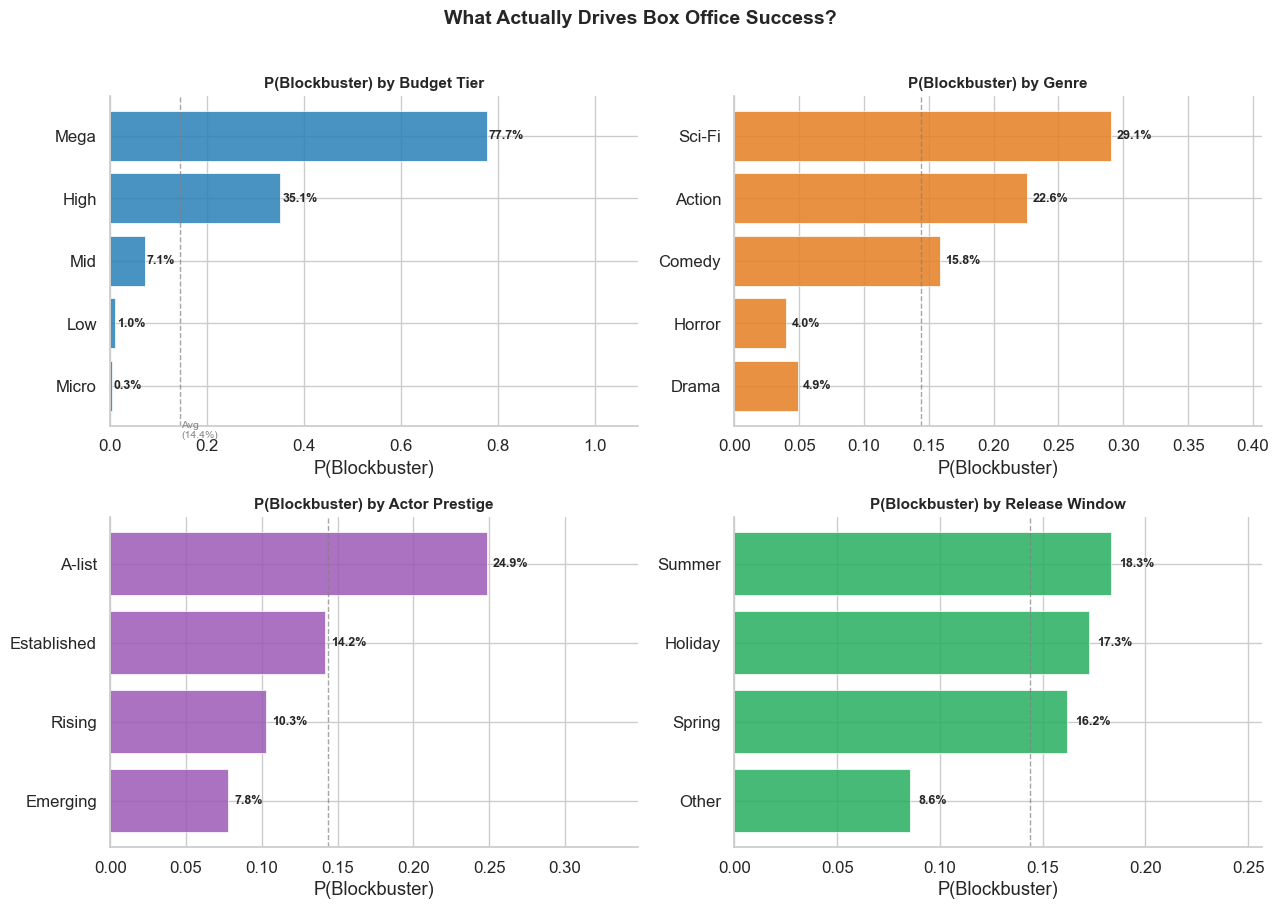

In [97]:
# What actually drives box office success?
# 2x2 grid: P(Blockbuster) for every category of each feature, vs dataset average

DATASET_AVG_BB = 471 / 3278  # 14.4% base rate

feature_configs = [
    ('budget_tier',    ['Micro', 'Low', 'Mid', 'High', 'Mega'],          '#2980b9', 'Budget Tier'),
    ('genre_bn',       ['Drama', 'Horror', 'Comedy', 'Action', 'Sci-Fi'],'#e67e22', 'Genre'),
    ('prestige_tier',  ['Emerging', 'Rising', 'Established', 'A-list'],  '#9b59b6', 'Actor Prestige'),
    ('release_window', ['Other', 'Spring', 'Holiday', 'Summer'],         '#27ae60', 'Release Window'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (feat, order, color, title) in zip(axes.flat, feature_configs):
    probs = [query_outcome({feat: v}).get('Blockbuster', 0) for v in order]
    bars  = ax.barh(order, probs, color=color, alpha=0.85, edgecolor='white', linewidth=0.6)
    for bar, p in zip(bars, probs):
        ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height() / 2,
                f'{p:.1%}', va='center', fontsize=9, fontweight='bold')
    ax.axvline(DATASET_AVG_BB, color='grey', linestyle='--', linewidth=1.0, alpha=0.7)
    ax.set_xlim(0, max(probs) * 1.4)
    ax.set_title(f'P(Blockbuster) by {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('P(Blockbuster)')
    sns.despine(ax=ax)

# Dataset average label on first subplot only
axes[0, 0].text(DATASET_AVG_BB + 0.003, -0.55, f'Avg\n({DATASET_AVG_BB:.1%})',
                fontsize=7.5, color='grey', va='top')

plt.suptitle('What Actually Drives Box Office Success?', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'conclusion_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

## The Blockbuster Formula — Conclusions

---

### What This Notebook Does

This notebook is structured as a **two-layer model** of box office success across 3,278 English-language films released between 2000 and 2025.

| Layer | Model | Job |
|---|---|---|
| **Layer 1** | Bayesian Network | *Explanation* — 4-class probability reasoning with interpretable pre-release features |
| **Layer 2** | Gradient Boosting | *Prediction* — binary Blockbuster / Not Blockbuster with 93.9% accuracy and 0.969 ROC AUC |
| **Context** | Era analysis | How theatrical risk changed from the franchise boom through the COVID shock |

The separation is deliberate. The BN answers **"what drives outcomes and by how much?"** The GB model answers **"given everything we know, is this film likely to be a Blockbuster?"**

---

### The Binary Blockbuster Formula (Gradient Boosting)

The GB model is the notebook's prediction engine. Its feature importance hierarchy reveals a clear formula:

**1. Budget is the dominant lever (54.5%)**
Studios only commit mega-budgets to films they expect to perform. That budget then funds the marketing reach that compounds into box office. Budget is simultaneously a studio greenlight signal and a causal amplifier.

**2. Audience scale matters more than quality (vote count 25.9% + popularity 13.1% = 39%)**
Being seen and talked about predicts commercial success far better than being rated highly. Vote average contributes only 1.9% — roughly 20× less than the two audience-scale signals combined.

**3. Genre matters, but only at the margins (< 1% per genre flag)**
Animation and Family flags appear because those genres reliably draw large audiences. But no single genre swings blockbuster probability the way budget or audience engagement does.

**4. The feature space is genuinely independent (all VIF < 2)**
The multicollinearity check showed no problematic redundancy. PCA needs 20 of 33 components to retain 95% of variance — the features spread information broadly rather than concentrating it in 2–3 dimensions.

> **The binary blockbuster formula in one sentence:**
> Spend big, target scalable genres, and let audience engagement do the rest — the GB model's 0.969 AUC confirms these three variables dominate the prediction signal.

---

### Why the Bayesian Network Stays

The BN reaches ~45% four-class accuracy. That number is honest, and it is not the point.

The BN is constrained to four coarse categorical inputs and a target that blends absolute revenue scale with ROI efficiency — two films can share the exact same profile on budget tier, genre, prestige, and release window yet land in different outcome buckets. Hard-label accuracy cannot capture that.

What the BN does instead:

- **Returns a probability distribution** across all four outcomes, not a single hard label
- **Supports scenario reasoning** — "what happens to P(Blockbuster) if I move from Mid to Mega budget?"
- **Exposes causal structure** — which variables matter most and how they interact
- **Makes the model auditable** — every probability is traceable back to the training data

In other words: the BN is here to explain the formula, not to win the prediction contest.

---

### What the Bayesian Network Reveals

**Budget is the dominant lever** — ablation shows the largest accuracy drop when `budget_tier` is removed. Mega-budget films live in a fundamentally different probability regime.

**Genre is the second structural driver** — Sci-Fi and Action carry higher blockbuster upside than Drama or Horror. Some genres scale naturally toward theatrical breakout.

**Actor prestige amplifies but does not create** — star power helps at the top end but is a weaker signal than budget and genre.

**Release timing is mostly cosmetic** — the BN ablation shows release window contributes little incremental signal once budget, genre, and prestige are known.

---

### Data Limitations

- **Worldwide box office only** — excludes streaming, home video, and merchandising revenue
- **Budget data incomplete** — many TMDb entries have missing or zero budgets; the cleaned dataset has selection pressure
- **TMDb engagement signals are post-release** — vote count and popularity improve prediction accuracy but are not available pre-production
- **Actor prestige is measured in April 2026** — not at the film's release date; older stars may have inflated or deflated scores
- **English-language bias** — TMDb popularity ranking over-represents wide-release, English-language films

---

### Final Takeaway

| Question | Answer |
|---|---|
| What drives box office outcomes? | **Bayesian Network** — interpretable, probabilistic, pre-release |
| Is this specific film a Blockbuster? | **Gradient Boosting** — 93.9% accuracy, 0.969 ROC AUC |
| How did the market change over time? | **Era analysis** — blockbuster rate peaked 2014–2019, collapsed during COVID, remains subdued post-streaming |


## Era Analysis - How Theatrical Risk Changed Over Time

To complement the feature-based Bayesian analysis, this final section looks at how **blockbuster rate** and **flop rate** evolved across distinct theatrical eras. The goal is not to claim the era itself causes performance, but to show how the background market environment changed between the early-2000s multiplex period, the superhero/franchise boom, the late-2010s blockbuster peak, the COVID shock, and the post-COVID streaming era.

We define five eras:

- **Early 2000s Reset**: 2000-2007
- **Superhero / Franchise Boom**: 2008-2014
- **Peak Blockbuster Era**: 2015-2019
- **COVID Shock**: 2020-2021
- **Post-COVID Streaming Era**: 2022-2025


,market_era,blockbuster_rate,flop_rate,film_count,median_revenue_adj_m
0,Early 2000s Reset,11.0%,28.0%,1157,$97M
1,Superhero / Franchise Boom,15.5%,22.1%,976,$104M
2,Peak Blockbuster Era,20.7%,21.6%,619,$105M
3,COVID Shock,7.7%,50.7%,142,$36M
4,Post-COVID Streaming Era,14.1%,30.2%,384,$62M


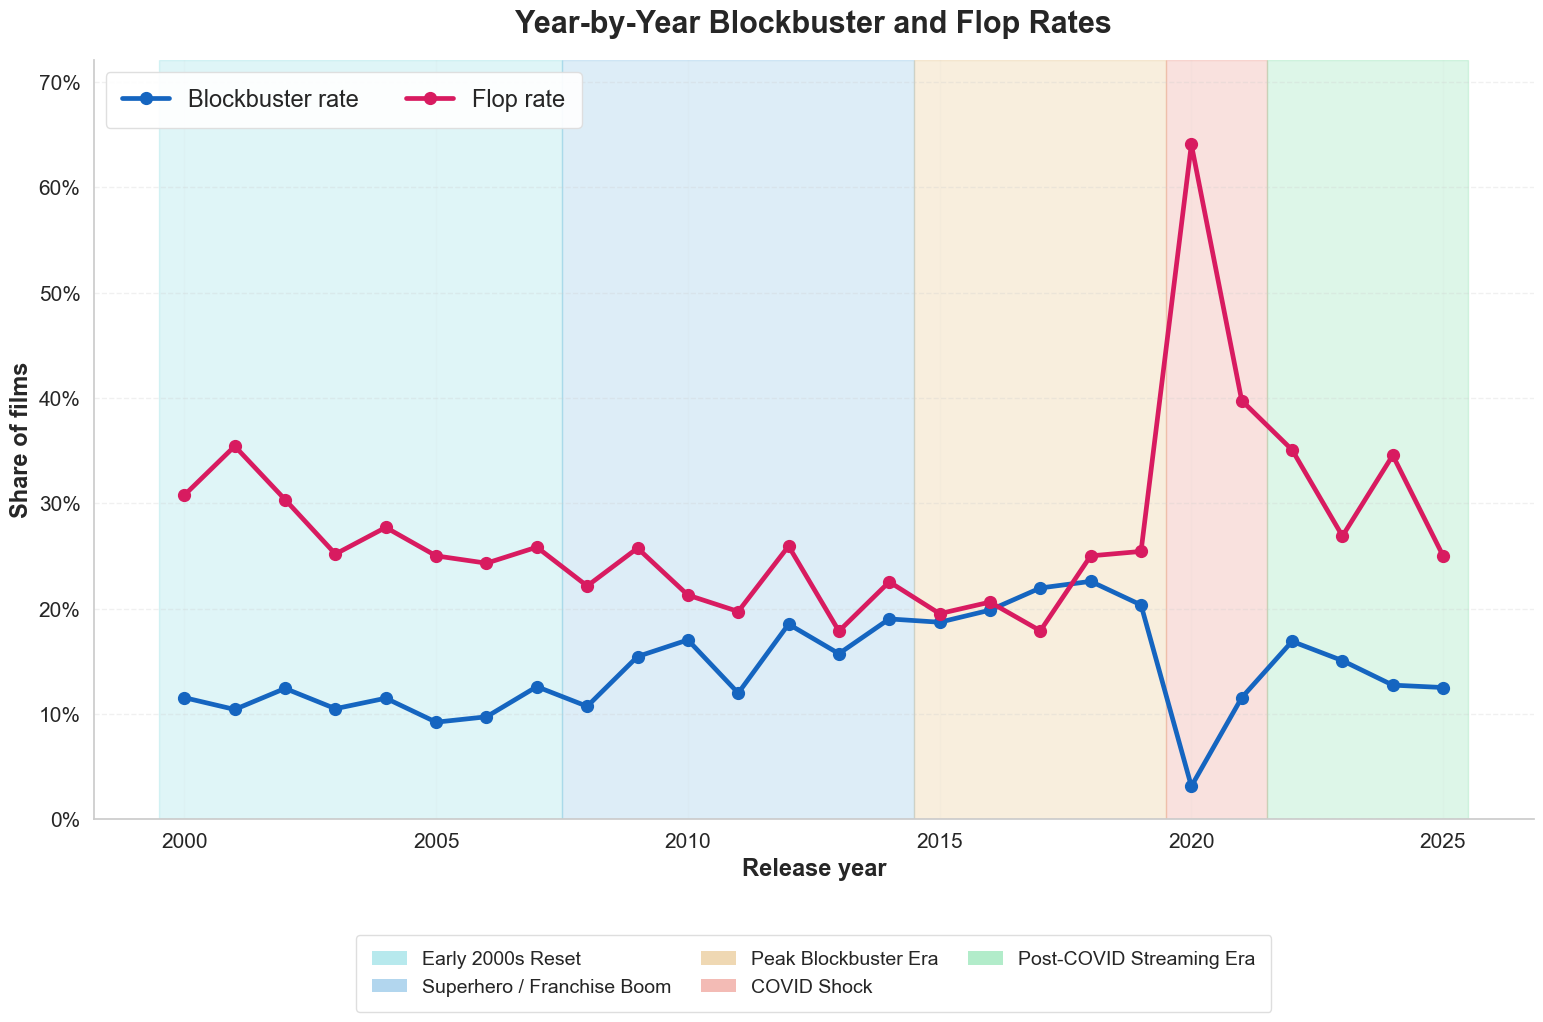

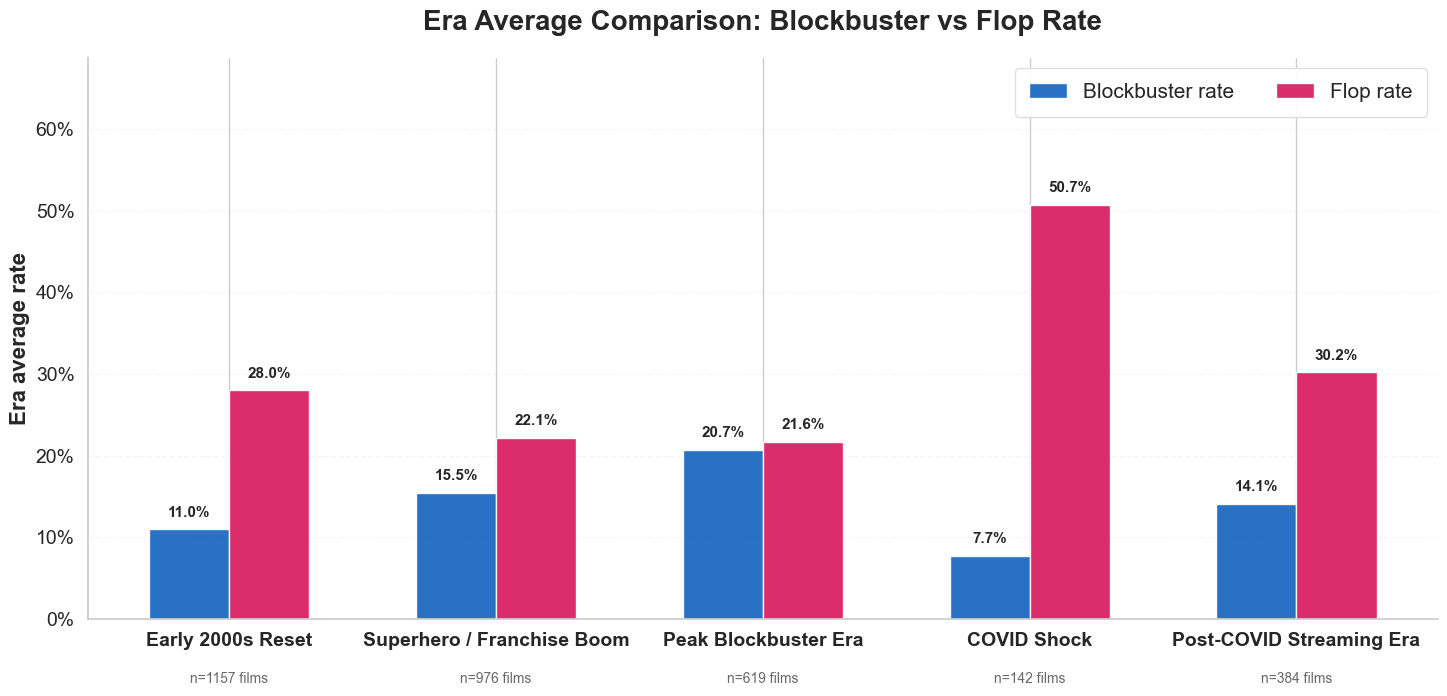

Highest blockbuster rate: Peak Blockbuster Era (20.7%)
Highest flop rate:        COVID Shock (50.7%)
Figures saved to outputs/era_blockbuster_flop_timeline.png and outputs/era_rate_comparison.png


In [98]:
# Era analysis: blockbuster and flop rates over time

era_bins = [1999, 2007, 2014, 2019, 2021, 2025]
era_labels = [
    'Early 2000s Reset',
    'Superhero / Franchise Boom',
    'Peak Blockbuster Era',
    'COVID Shock',
    'Post-COVID Streaming Era',
]

df_era = df_feat.copy()
df_era['market_era'] = pd.cut(
    df_era['release_year'],
    bins=era_bins,
    labels=era_labels,
    include_lowest=True,
    right=True,
)

yearly_rates = (
    df_era.groupby('release_year')
    .apply(lambda g: pd.Series({
        'blockbuster_rate': (g['outcome_label'] == 'Blockbuster').mean(),
        'flop_rate':        (g['outcome_label'] == 'Flop').mean(),
        'film_count':       len(g),
    }))
    .reset_index()
)

era_summary = (
    df_era.groupby('market_era', observed=False)
    .apply(lambda g: pd.Series({
        'blockbuster_rate': (g['outcome_label'] == 'Blockbuster').mean(),
        'flop_rate':        (g['outcome_label'] == 'Flop').mean(),
        'film_count':       len(g),
        'median_revenue_adj_m': g['revenue_adj'].median() / 1e6,
    }))
    .reindex(era_labels)
    .reset_index()
)

display(era_summary.style.format({
    'blockbuster_rate': '{:.1%}',
    'flop_rate': '{:.1%}',
    'film_count': '{:.0f}',
    'median_revenue_adj_m': '${:,.0f}M',
}))

era_spans = [
    (2000, 2007, 'Early 2000s Reset', "#21bcc7"),
    (2008, 2014, 'Superhero / Franchise Boom', "#1281cb"),
    (2015, 2019, 'Peak Blockbuster Era', "#cf8714"),
    (2020, 2021, 'COVID Shock', "#da2d19"),
    (2022, 2025, 'Post-COVID Streaming Era', "#12c65d"),
]

# Plot 1: yearly timeline
timeline_max = max(yearly_rates['blockbuster_rate'].max(), yearly_rates['flop_rate'].max())
timeline_top = max(0.62, min(0.75, timeline_max + 0.08))
fig, ax = plt.subplots(figsize=(16, 11.5))

for start, end, label, color in era_spans:
    ax.axvspan(start - 0.5, end + 0.5, color=color, alpha=0.14, zorder=0)

ax.plot(yearly_rates['release_year'], yearly_rates['blockbuster_rate'],
        marker='o', markersize=8.5, linewidth=3.4, color='#1565c0', label='Blockbuster rate', zorder=3)
ax.plot(yearly_rates['release_year'], yearly_rates['flop_rate'],
        marker='o', markersize=8.5, linewidth=3.4, color='#d81b60', label='Flop rate', zorder=3)

for _, row in yearly_rates.iterrows():
    if row['film_count'] < 25:
        ax.scatter(row['release_year'], row['blockbuster_rate'], s=55, facecolors='none', edgecolors='black', linewidths=0.9)

ax.set_title('Year-by-Year Blockbuster and Flop Rates', fontsize=22, fontweight='bold', pad=20)
ax.set_ylabel('Share of films', fontsize=17, fontweight='bold')
ax.set_xlabel('Release year', fontsize=17, fontweight='bold')
ax.set_ylim(0, timeline_top)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis='y', linestyle='--', alpha=0.28, linewidth=1.0)
ax.grid(axis='x', alpha=0.08)
ax.set_axisbelow(True)
ax.tick_params(axis='both', labelsize=15)
line_legend = ax.legend(frameon=True, fancybox=True, framealpha=0.92, edgecolor='#dddddd',
                        ncol=2, loc='upper left', fontsize=17, borderpad=0.7, handlelength=2.0)
era_handles = [mpatches.Patch(facecolor=color, edgecolor='none', alpha=0.32, label=label) for _, _, label, color in era_spans]
era_legend = ax.legend(handles=era_handles, frameon=True, fancybox=True, framealpha=0.95, edgecolor='#dddddd',
                       ncol=3, fontsize=14, loc='upper center', bbox_to_anchor=(0.5, -0.14),
                       columnspacing=1.5, handlelength=1.8, borderpad=0.8)
ax.add_artist(line_legend)
sns.despine(ax=ax)
fig.subplots_adjust(top=0.88, bottom=0.22, left=0.08, right=0.98)
plt.savefig(OUTPUTS_PATH / 'era_blockbuster_flop_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: era-average comparison
fig, ax = plt.subplots(figsize=(15, 8.5))
x = np.arange(len(era_summary))
w = 0.30
bars1 = ax.bar(x - w/2, era_summary['blockbuster_rate'], width=w, color='#1565c0', alpha=0.92, label='Blockbuster rate')
bars2 = ax.bar(x + w/2, era_summary['flop_rate'], width=w, color='#d81b60', alpha=0.92, label='Flop rate')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

for i, n in enumerate(era_summary['film_count']):
    ax.text(i, -0.065, f'n={int(n)} films', ha='center', va='top', fontsize=10, color='dimgray')

wrapped_labels = [
    'Early 2000s Reset',
    'Superhero / Franchise Boom',
    'Peak Blockbuster Era',
    'COVID Shock',
    'Post-COVID Streaming Era',
]

ax.set_xticks(x)
ax.set_xticklabels(wrapped_labels, fontsize=15, fontweight='bold')
ax.set_ylabel('Era average rate', fontsize=16, fontweight='bold')
ax.set_title('Era Average Comparison: Blockbuster vs Flop Rate', fontsize=20, fontweight='bold', pad=20)
ax.set_ylim(0, max(era_summary['flop_rate'].max(), era_summary['blockbuster_rate'].max()) + 0.18)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis='y', linestyle='--', alpha=0.20)
ax.set_axisbelow(True)
ax.tick_params(axis='both', labelsize=14)
ax.legend(frameon=True, fancybox=True, framealpha=0.94, edgecolor='#dddddd',
          ncol=2, loc='upper right', fontsize=15, borderpad=0.7, handlelength=1.8)
sns.despine(ax=ax)
fig.subplots_adjust(top=0.88, bottom=0.22, left=0.08, right=0.98)
plt.savefig(OUTPUTS_PATH / 'era_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_bb = era_summary.loc[era_summary['blockbuster_rate'].idxmax()]
worst_flop = era_summary.loc[era_summary['flop_rate'].idxmax()]
print(f"Highest blockbuster rate: {best_bb['market_era']} ({best_bb['blockbuster_rate']:.1%})")
print(f"Highest flop rate:        {worst_flop['market_era']} ({worst_flop['flop_rate']:.1%})")
print('Figures saved to outputs/era_blockbuster_flop_timeline.png and outputs/era_rate_comparison.png')
